# Agents for Data Quality — NoiPA

**A multi-agent pipeline that audits a raw public-administration CSV, repairs it under human approval, and scores what it delivered.**

Allam Eliya · Cervelli Mattia · Filosofi Simone — Machine Learning, A.A. 2025/26, in collaboration with Reply

---

This notebook explains the pipeline end to end. It **imports and runs the real production code** rather than restating it: every source listing below is fetched from the module that actually executes, with `inspect.getsource`, so nothing shown here can drift from what runs. Where a file is long or repetitive we show the part that carries the argument and name the rest. That code is the installed package `src/noipa_dq/`; a path written `agents/…`, `tools/…`, `prompts/…` or `utils/…` in the text below is relative to it, so `tools/fix_invariants.py` means `src/noipa_dq/tools/fix_invariants.py`.

It is runnable top to bottom in two modes, set in Section 2:

- **`LIVE_RUN = False`** (default) — replays the completed run recorded under `reports/runs/spesa/`, which is committed to this repository. No API key, no network, no cost. Every figure is read from the run that produced it.
- **`LIVE_RUN = True`** — records a fresh run of all twelve nodes against `spesa.csv` through `record_run.py`, overwriting `reports/runs/spesa/`. Takes about eleven minutes and needs `DEEPSEEK_API_KEY`, `OPENAI_API_KEY` and, for the sandbox layer of Section 9.3, `E2B_API_KEY`.

Both modes read the same artefacts from Section 11 onward, because the live mode writes exactly the directory the replay reads.

**For a live run we recommend the Streamlit application rather than `LIVE_RUN = True`.** This notebook is built to *explain* the pipeline, and its live mode reflects that: a notebook has nowhere to put a human decision, so `record_run.py` approves every proposal and Section 12 reports that decision rather than making one. Setting the flag also rewrites `reports/runs/spesa/`, the recorded run this notebook replays and the figures in the README are drawn from.

The application **is** the gate. It runs all twelve nodes on any CSV you upload, renders every proposal with the source that would execute, and lets you accept, reject or revise each one before anything reaches the data:

```bash
streamlit run app/streamlit_app.py
```

Section 2 ends with a cell that starts it for you.

## 1. Introduction and architecture

The problem is not detecting defects — counting nulls is trivial. It is the **gap between noticing a defect and being allowed to act on it**.

A wrong dtype, a null hiding behind the string `N/D`, two columns holding the same field under different names, a value contradicting the row it sits in, and a statistical outlier are five different problems. They rest on different evidence, they carry different risk and, the point the whole architecture turns on, they deserve **different authority**. Some the data itself determines, while the system applies them alone. Some require a judgement a machine should not make by itself, and only ever reach a human as a *proposal*. Some have no honest fix at all and are reported as such.

That division is the contribution. The pipeline is twelve LangGraph nodes in four phases:

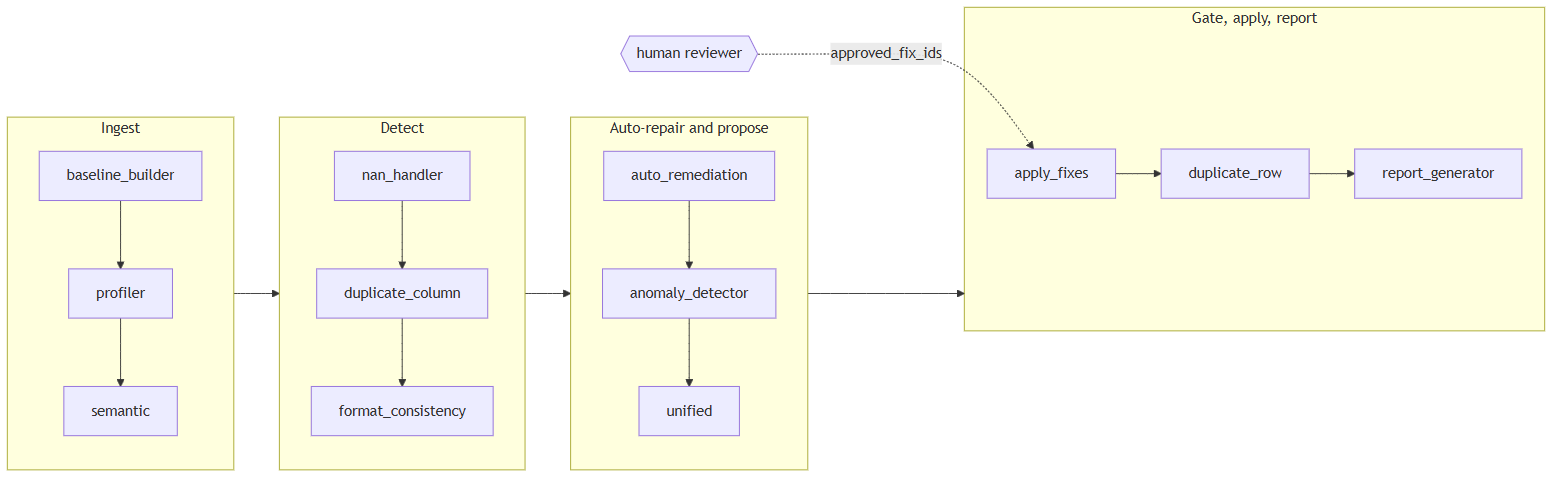

<!-- Diagram source (mermaid), rendered to the image above so it displays in every viewer.
Regenerate with:  npx @mermaid-js/mermaid-cli -i diagram.mmd -o diagram.png -b white -s 2

flowchart LR
  subgraph I["Ingest"]
    direction TB
    A[baseline_builder] --> B[profiler] --> C[semantic]
  end
  subgraph D["Detect"]
    direction TB
    E[nan_handler] --> F[duplicate_column] --> G[format_consistency]
  end
  subgraph P["Auto-repair and propose"]
    direction TB
    H[auto_remediation] --> J[anomaly_detector] --> K[unified]
  end
  subgraph R["Gate, apply, report"]
    direction TB
    L[apply_fixes] --> M[duplicate_row] --> N[report_generator]
  end
  I --> D --> P --> R
  HUMAN{{"human reviewer"}} -. approved_fix_ids .-> L
-->

Read as layers rather than as a sequence, the same system is:

| Layer | What it does | Where it lives |
|---|---|---|
| **1 · Deterministic measurement** | every count, rate, bound, violation and mined rule — pure pandas, no model | `tools/` |
| **2 · Bounded model reasoning** | each agent gets a packaged evidence bundle, never the dataframe, and returns a typed artefact | `agents/`, `prompts/` |
| **3 · Authority separation** | data-determined → applied · judgement → proposed to a human · unfixable → reported | `auto_remediation`, `unified`, `apply_fixes` |
| **4 · Execution and audit** | typed operations and gated generated code, invariant-checked, cell-level change log, re-measurement | `tools/operations.py`, `tools/fix_invariants.py`, `tools/change_log.py` |

Two properties that usually trade off therefore coexist: the system is **free to reason semantically** at layer 2, and **unable to act on that reasoning unchecked** at layers 3 and 4.

## 2. Setup and configuration

`LIVE_RUN` is the one switch that matters. Leave it `False` to replay the recorded run; set it `True` to execute the pipeline for real.

In [141]:
from __future__ import annotations

import inspect
import json
import sys
import textwrap
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT / "scripts"))

import figures

load_dotenv(ROOT / ".env", override=True)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

LIVE_RUN = False

DATASET = ROOT / "data" / "raw" / "project_data_quality" / "spesa.csv"
RUN_DIR = ROOT / "reports" / "runs" / "spesa"
REPORT_JSON = RUN_DIR / "spesa.json"

print("live run:", LIVE_RUN)
print("dataset :", DATASET.relative_to(ROOT))
print("artefacts:", RUN_DIR.relative_to(ROOT))

live run: False
dataset : data\raw\project_data_quality\spesa.csv
artefacts: reports\runs\spesa


The gate itself, launched from here. `LAUNCH_APP` stays `False` so that running this notebook top to bottom never starts a server; set it `True` to open the application. The command uses this kernel's own interpreter, so it works whether or not `streamlit` is on your `PATH`.

In [142]:
LAUNCH_APP = False   # True starts the Streamlit gate from this cell

if LAUNCH_APP:
    import subprocess

    app = subprocess.Popen(
        [sys.executable, "-m", "streamlit", "run", str(ROOT / "app" / "streamlit_app.py")],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.STDOUT,
    )
    print(f"streamlit running as pid {app.pid} -> http://localhost:8501")
    print("stop it from this notebook with: app.terminate()")
else:
    print("LAUNCH_APP is False - nothing started.")
    print("Set it True and re-run this cell, or from a terminal at the repository root:")
    print()
    print("    streamlit run app/streamlit_app.py")

LAUNCH_APP is False - nothing started.
Set it True and re-run this cell, or from a terminal at the repository root:

    streamlit run app/streamlit_app.py


`show` is the workhorse of this notebook. It prints the source of a live object straight from the module that defines it, so every listing below is the code that runs — it cannot be a stale copy. `show_file` does the same for a slice of a file, used where only part of a long function carries the argument.

In [143]:
def show(obj) -> None:
    """Renders the source of a function or class as it exists at runtime."""
    source = inspect.getsource(obj).rstrip()
    display(Markdown(f"```python\n{source}\n```"))


def show_file(path: str, start: int = 1, end: int | None = None, lang: str = "python") -> None:
    """Renders a slice of a source file, 1-indexed and inclusive."""
    lines = (ROOT / path).read_text(encoding="utf-8").splitlines()
    chunk = "\n".join(lines[start - 1:end])
    display(Markdown(f"```{lang}\n{chunk}\n```"))


def show_markdown(path: str, until: str | None = None) -> None:
    """Renders a markdown file, truncated at the first line starting with `until`."""
    text = (ROOT / path).read_text(encoding="utf-8")
    if until and until in text:
        text = text[:text.index(until)].rstrip() + "\n\n*[...]*"
    display(Markdown(text))

## 3. The dataset

`spesa.csv` is public expenditure by administration and tax code. It is used throughout because it carries all five defect categories at once. The raw file is loaded here exactly as it arrives.

In [144]:
raw = pd.read_csv(DATASET)
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(3)

7,543 rows x 18 columns


,_id,rata,ente,descrizione,cod_tipoimposta,tipo_imposta,cod_imposta,imposta,spesa,aggregation-time,area_geografica,note,fonte_dato,Tipo Imposta,SPESA TOTALE,2cod_imposta,cod imposta ext,ente%code
0,65ee5ac5f458af56d2af532f,202402,867,AGENZIA ITALIANA DEL FARMACO - AIFA,2,Erariali,6,IRAP,182904.47999999954,2024-03-11T02:01:04.421,Nord,NaN,NaN,Erariali,182904.47999999954,6,6,867
1,668f34120377f62206882cd8,202406,921,A.O. S. GIOVANNI ADDOLORATA,3,Previdenziali,13,Previdenziali a carico del datore di lavoro,2110811.34,2024-07-11T03:01:16.866,Nord,NaN,NaN,Previdenziali,2110811.34,13,13,921
2,66e0ee64f458af54a5dbc7fa,202408,9,MINISTERO DELLA GIUSTIZIA,4,Varie,10,Ritenute Sindacali,732614.36,2024-09-11T03:01:11.704,Nord,NaN,NaN,Varie,732614.36,10,10,9


The header row alone already shows three separate problems. Read it before reading anything else:

In [145]:
for name in raw.columns:
    print(f"  {name}")

  _id
  rata
  ente
  descrizione
  cod_tipoimposta
  tipo_imposta
  cod_imposta
  imposta
  spesa
  aggregation-time
  area_geografica
  note
  fonte_dato
  Tipo Imposta
  SPESA TOTALE
  2cod_imposta
  cod imposta ext
  ente%code


- **The same field under three names.** `cod_imposta`, `2cod_imposta` and `cod imposta ext` are one column wearing three headers. So are `ente` / `ente%code`, `tipo_imposta` / `Tipo Imposta`, and `spesa` / `SPESA TOTALE`.
- **Convention drift inside the header itself.** `_id`, `aggregation-time`, `ente%code`, `2cod_imposta`, `SPESA TOTALE` each break the registry's naming rule in a different way.
- **Nulls that pandas cannot see.** The count below is what `isna()` believes; Section 11 shows what it misses.

In [146]:
summary = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "nulls_seen_by_pandas": raw.isna().sum(),
    "distinct": raw.nunique(dropna=True),
})
summary["fill_rate"] = (1 - summary["nulls_seen_by_pandas"] / len(raw)).round(4)
summary.sort_values("fill_rate")

,dtype,nulls_seen_by_pandas,distinct,fill_rate
fonte_dato,object,7468,1,0.0099
note,object,7393,4,0.0199
area_geografica,object,1582,4,0.7903
descrizione,object,169,113,0.9776
imposta,object,137,22,0.9818
ente,object,118,89,0.9844
cod_imposta,object,72,18,0.9905
_id,object,0,7478,1.0000
cod_tipoimposta,int64,0,4,1.0000
tipo_imposta,object,0,10,1.0000


Two columns are nearly empty — `note` and `fonte_dato` are over 98% null — and no amount of inference can recover what they do not hold. Section 10 shows the invariant that forbids trying.

The disguised nulls are the more interesting case, because nothing above reveals them. The
count on the left is what `isna()` already saw; the count on the right is what it cannot. Note
that `area_geografica` returns zero — its 1,582 gaps are genuinely empty, not disguised, which
is why Section 12.2 ends up carrying them to the report with no corrective action:

In [147]:
PLACEHOLDER_SPELLINGS = ["n/d", "nd", "n.d.", "-", "--", "?", "", "nan", "null", "9999"]

for column in ("ente", "imposta", "area_geografica"):
    present = raw[column].dropna().astype(str).str.strip()
    counts = present.value_counts()
    disguised = counts[counts.index.str.lower().isin(PLACEHOLDER_SPELLINGS)]
    print(f"{column}: {raw[column].isna().sum()} nulls pandas sees, "
          f"{disguised.sum()} more standing in for one")
    for value, n in disguised.items():
        print(f"    {value!r:12} x {n}")
    print()

ente: 118 nulls pandas sees, 126 more standing in for one
    ''           x 29
    '?'          x 29
    'n.d.'       x 24
    '-'          x 24
    'ND'         x 20

imposta: 137 nulls pandas sees, 175 more standing in for one
    'n.d.'       x 44
    '-'          x 39
    'ND'         x 33
    '?'          x 31
    ''           x 28

area_geografica: 1582 nulls pandas sees, 0 more standing in for one



## 4. The knowledge base

The pipeline is grounded in two hand-curated files that together form a semi-RAG knowledge base of NoiPA's canonical data model. Both were written by hand from **NoiPA open data**: we downloaded a set of published datasets, read their fields and distilled the recurring columns, domains and conventions into a registry. It is curation, not extraction — a registry states what a field *should* be, which no single file can tell you. To make the registry always more precise and at the same time cover a broader set of knowledge, more official NoiPA datasets can be downloaded and added.

In [148]:
registry = json.loads(
    (ROOT / "data" / "registry" / "noipa_schema_registry.json").read_text(encoding="utf-8")
)["NoiPA_Schema_Registry"]

shared = [name for name in registry["shared_column_definitions"] if not name.startswith("_")]
print("domains:", list(registry["domains"]))
print("shared column definitions:", len(shared))
print("dataset definitions:", sum(len(d.get("datasets", {})) for d in registry["domains"].values()))

domains: ['Amministrati', 'Amministrazioni', 'Rapporti_di_lavoro', 'Trattamento_economico']
shared column definitions: 12
dataset definitions: 19


`baseline_builder` resolves every `$ref` against the shared block and validates the whole structure into a `BaselineFile`, written out as `baseline.json`, so no downstream agent ever has to interpret a reference itself. The global conventions below are what the naming and format checks validate against for the rest of the run.

In [149]:
baseline = json.loads((ROOT / "data" / "registry" / "baseline.json").read_text(encoding="utf-8"))
baseline["global_conventions"]

{'naming_convention': 'snake_case_lower_with_uppercase_acronym_suffix',
 'naming_regex': '^[a-z][a-z0-9_]*(_[A-Z]{2,})?$',
 'encoding': 'utf-8',
 'csv_separator': ',',
 'decimal_separator': '.',
 'filename_convention_monthly': 'EntryDatasetName_YYYYMM.csv',
 'filename_convention_annual': 'EntryDatasetName_YYYY.csv',
 'k_anonymity_floor_for_person_counts': 6}

The second file is the retrieval index. Each canonical column carries a natural-language description and sample values; the pair is embedded once with `text-embedding-3-small` and cached to `column_descriptions.embeddings.pkl`. This is what makes canonical matching work on columns whose names carry no signal at all — `2cod_imposta` matches nothing by name, but its description and values do.

In [150]:
descriptions = json.loads(
    (ROOT / "data" / "registry" / "column_descriptions.json").read_text(encoding="utf-8")
)
print(f"{len(descriptions)} canonical columns indexed\n")
for entry in descriptions[:2]:
    print(json.dumps(entry, ensure_ascii=False, indent=1)[:420], "\n")

54 canonical columns indexed

{
 "column_name": "aliquota_max",
 "description": "Maximum IRPEF marginal tax rate (%) applied to the income bracket of the group.",
 "sample": [
  "23",
  "35",
  "43"
 ],
 "dtype": "integer"
} 

{
 "column_name": "amministrazione",
 "description": "Name of the public administration entity to which the employees belong.",
 "sample": [
  "A.O. S. GIOVANNI ADDOLORATA",
  "AGENZIA ITALIANA PER LA COOPERAZIONE ALLO SVILUPPO",
  "AUTORITA' DI BACINO DISTRETTUALE DELL'APPENNINO CENTRALE",
  "AZIENDA SANITARIA LOCALE ROMA 2",
  "COMUNE DI MERCATO SAN SEVERINO",
  "ENTE PARCO NAZIONALE DELLA MAJELLA",
  "ISTITUTO SUP 



## 5. The typed contracts

Every handoff between stages is a validated Pydantic model declared in `models.py`. A stage does not return prose, or a dict, or a dataframe with an understanding attached — it returns an object that either validates or fails loudly.

In a pipeline of this class the main risk is not that a model returns something wrong, it is that it returns something **plausible that nobody can check**. A typed artefact converts that risk into a validation error at the boundary.

`models.py` declares twenty-five models. Six of them carry the pipeline, and those are the ones worth reading.

### 5.1 What a column *means* — `ColumnPayload`

Produced by the Semantic agent, consumed by everything downstream. `canonical_hint` is the field the rest of the run depends on: it decides which format spec applies, whether nulls are allowed, and which columns are grouped together for remediation.

In [151]:
from noipa_dq.models import ColumnPayload
show(ColumnPayload)

```python
class ColumnPayload(BaseModel):
    column_name: str
    description: str
    dtype: str
    sample: list[Any] = Field(default_factory=list)
    placeholders: list[Any] = Field(default_factory=list)
    related_columns: list[str] = Field(default_factory=list)
    target_casing: Casing = Casing.as_is
    canonical_hint: str = "NaN"
    canonical_candidates: list[dict] = Field(default_factory=list)
```

### 5.2 What is *wrong* with it — `FormatViolation` and `ValidationReport`

Every violation carries a `kind`, and that tag is what lets the reliability score attribute a defect to the right quality dimension without re-deriving it from the message text.

In [152]:
from noipa_dq.models import FormatViolation, ValidationReport, ViolationKind
show_file("src/noipa_dq/models.py", 104, 120)

```python
ViolationKind = Literal["format", "completeness", "schema", "consistency", "uniqueness"]


class FormatViolation(BaseModel):
    column_name: str
    row_index: int
    value: Any
    expected_pattern: str | None
    kind: ViolationKind
    affected_rows: int = 1


class ValidationReport(BaseModel):
    column_name: str
    violations: list[FormatViolation] = Field(default_factory=list)
    detected_total: int | None = None

```

### 5.3 What the system is *capable of doing* — `Operation`

`OperationKind` is a closed `Literal`, and this is deliberate: it is the complete enumeration of everything the system can do to a dataset. Anything not on this list cannot be executed, whatever an agent proposes.

In [153]:
from noipa_dq.models import Operation, ValueMapping
show_file("src/noipa_dq/models.py", 122, 152)

```python
OperationKind = Literal[
    "replace_values",
    "normalize_numeric",
    "normalize_date",
    "normalize_period",
    "strip_whitespace",
    "collapse_casing",
    "round_decimals",
    "cast_dtype",
    "impute_from_lookup",
    "drop_column",
    "rename_column",
    "drop_duplicate_rows",
    "apply_generated_function",
]


class ValueMapping(BaseModel):
    value: str
    replacement: str | None = None


class Operation(BaseModel):
    kind: OperationKind
    column: str = ""
    mapping: list[ValueMapping] = Field(default_factory=list)
    digits: int = 2
    dtype: str = ""
    new_name: str = ""
    subset: list[str] = Field(default_factory=list)
    source: str = ""
```

### 5.4 A proposed repair — `FixProposal`

The unit the human gate acts on. `id` is the handle that must appear in `state.approved_fix_ids` for anything to happen; `group_id` records which column group produced it, so a reviewer can send one group back for a re-proposal without disturbing the others.

In [154]:
from noipa_dq.models import FixProposal
show(FixProposal)

```python
class FixProposal(BaseModel):
    id: str
    description: str
    rationale: str
    addresses_violations: list[str] = Field(default_factory=list)
    affected_columns: list[str] = Field(default_factory=list)
    estimated_rows_affected: int = 0
    operations: list[Operation] = Field(default_factory=list)
    code: str = ""
    depends_on: list[str] = Field(default_factory=list)
    group_id: str = ""
```

### 5.5 A gap the data can close by itself — `ImputationHint`

Mined deterministically from the data, never proposed by a model. `purity` is the fraction of predictor groups mapping to a single target value, `coverage` the fraction of missing rows the mapping can fill. Auto-remediation acts alone only above purity 0.99; anything weaker is evidence handed to the Unified agent, not a licence to fill.

In [155]:
from noipa_dq.models import ImputationHint
show(ImputationHint)

```python
class ImputationHint(BaseModel):
    target_column: str
    strategy: Literal["lookup"] = "lookup"
    predictor_columns: list[str]
    mapping: dict[str, Any]
    path: Literal["raw", "normalized"]
    purity: float
    coverage: float
    confidence: Literal["strict", "dominant"]
    temporally_stable: bool = True
    rationale: str = ""
```

### 5.6 A defect with no honest fix — `UnaddressedViolations`

The contract that makes "we could not repair this" a first-class outcome rather than a silence. Without it, a violation that no proposal addresses simply disappears between detection and the report.

In [156]:
from noipa_dq.models import UnaddressedViolations
show(UnaddressedViolations)

```python
class UnaddressedViolations(BaseModel):
    """Violations carried to the report with no corrective action, and why none exists. The model
    declares its own where it can; the pipeline fills in what it fails to declare."""
    group_id: str
    columns: list[str] = Field(default_factory=list)
    violation_ids: list[str] = Field(default_factory=list)
    reason: str = ""
    affected_rows: int = 0
    affected_by_column: dict[str, int] = Field(default_factory=dict)
    actioned_elsewhere: list[str] = Field(default_factory=list)
    source: Literal["model", "pipeline"] = "model"
```

## 6. The shared state and the graph

### 6.1 `PipelineState`

One object travels the whole pipeline. Each node receives it and returns an updated copy — never a mutation — so any stage's output can be inspected in isolation and the run is reconstructible from any point.

In [157]:
from noipa_dq.state import PipelineState
show(PipelineState)

```python
class PipelineState(BaseModel):
    dataset: Any = None
    dataset_path: str = ""

    baseline: BaselineFile | None = None
    baseline_path: str = _DEFAULT_BASELINE_PATH

    detected_domain: str = ""
    detected_language: str = ""

    payload: list[ColumnPayload] = Field(default_factory=list)

    surviving_columns: list[str] = Field(default_factory=list)
    duplicate_resolutions: list[DuplicateResolution] = Field(default_factory=list)

    validation_reports: list[ValidationReport] = Field(default_factory=list)
    value_corrections: dict[str, dict[str, str | None]] = Field(default_factory=dict)
    inferred_format_specs: dict[str, dict] = Field(default_factory=dict)
    imputation_hints: dict[str, ImputationHint] = Field(default_factory=dict)

    anomaly_reports: list[AnomalyReport] = Field(default_factory=list)

    proposed_fixes: list[FixProposal] = Field(default_factory=list)
    fix_groups: dict[str, list[str]] = Field(default_factory=dict)
    approved_fix_ids: list[str] = Field(default_factory=list)
    applied_fix_ids: list[str] = Field(default_factory=list)
    auto_remediations: list[dict] = Field(default_factory=list)
    unaddressed_violations: list[UnaddressedViolations] = Field(default_factory=list)
    generated_function_runs: list[dict] = Field(default_factory=list)

    change_log: list[dict] = Field(default_factory=list)

    duplicate_rows: dict = Field(default_factory=dict)
    completeness: dict = Field(default_factory=dict)
    reliability: dict = Field(default_factory=dict)
    quality_snapshots: dict[str, dict] = Field(default_factory=dict)

    errors: list[str] = Field(default_factory=list)

    class Config:
        arbitrary_types_allowed = True
```

### 6.2 The wiring

The entire architecture is thirty-one lines. The order is fixed and there is no conditional routing: this is a sequence with one interruption point, not a free-routing agent swarm, and `graph.py` says so.

In [158]:
from noipa_dq import graph
show(graph.build_graph)

```python
def build_graph() -> StateGraph:
    g = StateGraph(PipelineState)

    g.add_node("baseline_builder", baseline_builder_node)
    g.add_node("profiler", profiler_node)
    g.add_node("semantic", semantic_node)
    g.add_node("nan_handler", nan_handler_node)
    g.add_node("duplicate_column", duplicate_column_node)
    g.add_node("format_consistency", format_consistency_node)
    g.add_node("auto_remediation", auto_remediation_node)
    g.add_node("anomaly_detector", anomaly_detector_node)
    g.add_node("unified", unified_node)
    g.add_node(APPROVAL_GATE_NODE, apply_fixes_node)
    g.add_node("duplicate_row", duplicate_row_node)
    g.add_node("report_generator", report_generator_node)

    g.set_entry_point("baseline_builder")
    g.add_edge("baseline_builder", "profiler")
    g.add_edge("profiler", "semantic")
    g.add_edge("semantic", "nan_handler")
    g.add_edge("nan_handler", "duplicate_column")
    g.add_edge("duplicate_column", "format_consistency")
    g.add_edge("format_consistency", "auto_remediation")
    g.add_edge("auto_remediation", "anomaly_detector")
    g.add_edge("anomaly_detector", "unified")
    g.add_edge("unified", APPROVAL_GATE_NODE)
    g.add_edge(APPROVAL_GATE_NODE, "duplicate_row")
    g.add_edge("duplicate_row", "report_generator")
    g.add_edge("report_generator", END)

    return g
```

The interruption point is `apply_fixes`, and it is a mechanism rather than a convention. The node executes **only** the ids present in `state.approved_fix_ids` and is a no-op otherwise: there is no code path by which a proposal reaches the dataset without an explicit id in that list.

In [159]:
from noipa_dq.agents.apply_fixes import apply_fixes_node
show_file("src/noipa_dq/agents/apply_fixes.py", 15, 22)

```python
def apply_fixes_node(state: PipelineState) -> PipelineState:
    if state.dataset is None:
        return state

    approved_ids = set(state.approved_fix_ids)
    approved = [p for p in state.proposed_fixes if p.id in approved_ids]
    statuses: list[dict] = []
    cleaned = state.dataset
```

### 6.3 The model behind every agent

`utils/llm.py` is the single construction point for the whole system: one place to change the model, the temperature, or the failure behaviour.

Two details matter. `temperature=0` with the provider's reasoning mode disabled bounds run-to-run variance — it does not remove it, as Section 15 shows with measurements. And schema-constrained answers take **two** decoding paths: tool calling first, then JSON mode, whose constrained decoding cannot emit invalid JSON. An answer neither path produces raises `EmptyModelResponse`, which a caller able to continue without it catches — so one unanswerable column group costs that group and no more, rather than the whole run.

In [160]:
import noipa_dq.utils.llm as llm
show(llm.structured_model)
show(llm._answer)

```python
def structured_model(
    schema: type[SchemaT], max_tokens: int | None = None
) -> Runnable[LanguageModelInput, SchemaT]:
    """A chain answering a chat-message list with an instance of schema."""
    model = ChatDeepSeek(
        model=MODEL,
        temperature=0,
        max_tokens=max_tokens,
        max_retries=_MAX_RETRIES,
        timeout=_REQUEST_TIMEOUT_SECONDS,
        extra_body=_REASONING_DISABLED,
    )
    by_tool_call = model.with_structured_output(schema)
    by_json_object = model.bind(response_format=_JSON_OBJECT)
    return RunnableLambda(
        lambda messages: _answer(schema, by_tool_call, by_json_object, messages)
    )
```

```python
def _answer(
    schema: type[SchemaT],
    by_tool_call: Runnable,
    by_json_object: Runnable,
    messages: LanguageModelInput,
) -> SchemaT:
    try:
        answer = by_tool_call.invoke(messages)
    except _UNPARSEABLE_TOOL_CALL:
        answer = None
    if answer is not None:
        return answer
    try:
        return _from_json_object(schema, by_json_object, messages)
    except _UNPARSEABLE_JSON_OBJECT as error:
        raise EmptyModelResponse(
            _UNUSABLE.format(model=MODEL, schema=schema.__name__)
        ) from error
```

## 7. The agents

Twelve nodes. **Six call a model directly**, one calls it indirectly through two tools, and five are pure Python. Which is which is itself an architectural statement: the stages that *measure* never call a model, and the stages that *reason* never measure.

| # | Node | Model? | Asked to decide | Returns | Phase |
|---|---|---|---|---|---|
| 1 | `baseline_builder` | — | nothing; resolves the registry | `BaselineFile` | Ingest |
| 2 | `profiler` | yes | which NoiPA domain and language this file is | domain, language | Ingest |
| 3 | `semantic` | yes | what each column means and which canonical it is | `ColumnPayload[]` | Ingest |
| 4 | `nan_handler` | — | nothing; unmasks, casts, measures completeness | `ValidationReport[]` | Detect |
| 5 | `duplicate_column` | yes | which name survives among redundant columns | `DuplicateResolution[]` | Detect |
| 6 | `format_consistency` | via tools | what format a column follows; how to correct a value | specs, rules, corrections | Detect |
| 7 | `auto_remediation` | — | nothing; applies only what the data determines | `auto_remediations[]` | Propose |
| 8 | `anomaly_detector` | yes | how to read the outliers already computed | `AnomalyReport[]` | Propose |
| 9 | `unified` | yes | what repair each violation needs, or that none exists | `FixProposal[]` | Propose |
| 10 | `apply_fixes` | — | nothing; executes approved ids only | applied ids, errors | Deliver |
| 11 | `duplicate_row` | — | nothing; removes exact duplicates | duplicate analysis | Deliver |
| 12 | `report_generator` | yes | what the figures *mean* — never what they are | narrative | Deliver |

The prompt of each model-calling agent lives in `prompts/<name>.md`, loaded through `utils/prompts.py`. A prompt is therefore a reviewable diff, not a string buried in code.

In [161]:
from noipa_dq.utils.prompts import load_prompt
show(load_prompt)

```python
def load_prompt(name: str) -> str:
    """Return the contents of prompts/<name>.md as a system-prompt string."""
    path = _PROMPTS_DIR / f"{name}.md"
    if not path.exists():
        raise FileNotFoundError(f"Prompt file not found: {path}")
    return path.read_text(encoding="utf-8")
```

### 7.1 Ingest — grounding the file in a canonical model

`profiler` is the first stage that calls a model, and it is asked for exactly two facts: which NoiPA domain this file belongs to, and what language its values are written in. It never receives the dataframe — only the column names, a sample per column, and the registry's signature map. The domain it returns is what scopes every later comparison against the baseline, which is why the prompt constrains the answer to the registry's own keys and gives `"altro"` as the explicit escape hatch rather than letting the model invent a domain.

In [162]:
show_markdown("src/noipa_dq/prompts/profiler.md", until="# Output format")

# Role
You are a data-profiling assistant specialised in Italian Public Administration (PA) datasets.

# Task
You will receive information about an unknown dataset: its column names and a sample of values from each column. You will also receive a hierarchical signature map of the reference baseline: each domain contains one or more datasets, and each dataset lists the canonical column names that have been observed for it across real Italian PA open-data sources.

Your job is to:
1. Identify which baseline **domain** this dataset most likely belongs to. Use the per-dataset signatures only as evidence to ground the domain choice — match by *meaning*, not by exact string. Input columns may differ in casing, language, accents, or use synonyms.
2. Identify the primary language of the string values (use ISO 639-1 codes, e.g. "it" for Italian, "en" for English).

# Input format
A JSON object with these keys:
- `baseline_signatures`: object mapping each domain name to an object mapping each dataset name to its array of canonical column names
- `column_names`: array of column name strings from the input dataset
- `sample_values`: object mapping each input column name to an array of up to 5 non-null sample values

# Rules
- `detected_domain` MUST be one of the keys in `baseline_signatures`, OR the literal string `"altro"` if no domain fits.
- Prefer the domain that contains the dataset (or datasets) whose canonical column set most overlaps with the input columns.
- Base language detection on actual string values, not column names. Most NoiPA-related datasets are Italian, so prefer `"it"` unless string values strongly indicate otherwise.
- Keep `rationale` to one or two sentences.

*[...]*

`semantic` is the stage the rest of the run depends on. It resolves each column to a canonical definition through a **cascade**: programmatic name and alias matching first; embedding retrieval over the description index where that is insufficient; then an explicit model verdict comparing descriptions, dtypes and sample values.

The agent never receives the dataframe. It receives a bounded instance: the column name, its dtype, a 30-row sample, the placeholder candidates found deterministically, and the retrieved canonical candidates. A wrong `canonical_hint` does not merely produce a wrong match — it silently retargets three later stages, which is why the match ends in a verdict rather than a similarity threshold.

In [163]:
show_markdown("src/noipa_dq/prompts/semantic.md", until="## Output")

# Semantic Agent Prompt

## Task
Analyze a single dataset column and return a structured semantic payload, possibly grounded in a canonical baseline definition from the NoiPA registry.

## Input
A JSON object with these fields:
- `column_name`: string
- `dataset_domain`: detected domain of the whole dataset (may be `"altro"` or empty when no NoiPA domain fits)
- `dtype`: pandas-inferred dtype string
- `sample`: up to 30 representative non-null values
- `all_column_names`: every column name in the dataset (for `related_columns`)
- `placeholder_candidates`: values literally observed in this column that match a curated list of generic disguised-NaN tokens, plus values that violate the canonical spec when one is provided. Filter — do not extend.
- `canonical_suggestion` (optional): a programmatic name-match from the NoiPA registry, with the shape
  `{canonical_id, dtype, format, case_convention, is_nullable}`. May be `null` when the cascade found no match.
- `canonical_candidates`: a ranked list of up to 5 baseline columns retrieved by semantic similarity
  (description embeddings boosted by sample-value overlap and dtype agreement). Each entry has the shape
  `{canonical_id, description, dtype, sample, score, format?, case_convention?, is_nullable?}`. The list is
  always provided even when `canonical_suggestion` is set — use it to confirm or override the name-based
  suggestion, especially when the input column name differs from the canonical id (synonym, different
  language, or paraphrase). Higher `score` means stronger retrieval evidence; the first entry is the
  retriever's best guess. Inspect `description` and `sample` to verify the meaning truly matches.

*[...]*

The deterministic half of the same stage: the placeholder vocabulary the agent is asked to filter, rather than to invent.

In [164]:
import noipa_dq.agents.semantic as semantic_agent
print(semantic_agent._PLACEHOLDERS)

['', '-', '--', '.', '..', '...', '//', '///', '?', '??', '???', '#', 'n/a', 'na', 'n.a.', '#n/a', 'n/d', 'nd', 'n.d.', '#n/d', '#nd', 'null', 'none', 'nan', 'unknown', 'missing', 'tbd', 'error', 'not available', 'not applicable', 'n/c', 'nc', 'n.c.', 'sconosciuto', 'non disponibile', 'non applicabile', 'da verificare', 'da definire', 'da inserire', 'da completare', 'in attesa', 'non pervenuto', 'non rilevato', 'non classificato', -1, 0, 999, -999, 9999, -9999, 99999, -99999]


### 7.2 Detect — measuring against the schema and against itself

`nan_handler` calls no model at all. It unmasks disguised nulls using the per-column lists from the payload, enforces the proposed dtype **non-destructively** — a column is cast only if every non-null value survives, and blocking values are reported rather than coerced away — and records the completeness analysis.

One guard here is worth its own sentence: a placeholder list is **refused if it matches more than 30% of a column**, because at that scale the list has stopped describing the gaps and started describing the column's own vocabulary.

In [165]:
import noipa_dq.agents.nan_handler as nan_handler
print("max placeholder share:", nan_handler._MAX_PLACEHOLDER_SHARE)
show(nan_handler._unmask_placeholders)

max placeholder share: 0.3


```python
def _unmask_placeholders(
    df: pd.DataFrame, state: PipelineState
) -> tuple[pd.DataFrame, list[ValidationReport]]:
    """Clears the placeholder tokens the Semantic agent listed, per column, unless doing so would
    empty the column. A list that matches most of a column is describing the column's own
    vocabulary rather than the gaps in it - a canonical enum stated in different words makes every
    value a spec violation - and applying it destroys the data it was meant to clean. The column
    is left as it stands and the rejection is reported so the gate can see it."""
    reports: list[ValidationReport] = []
    for p in state.payload:
        if p.column_name not in df.columns or not p.placeholders:
            continue
        series = df[p.column_name]
        cleared = detect_placeholders(series, p.placeholders)
        populated = int(series.notna().sum())
        removed = populated - int(cleared.notna().sum())
        if populated and removed / populated > _MAX_PLACEHOLDER_SHARE:
            reports.append(_rejected_placeholders_report(p.column_name, removed, populated))
            continue
        df[p.column_name] = cleared
    return df, reports
```

`duplicate_column` is the smallest model call in the pipeline and the most tightly constrained. Redundant columns are found deterministically — identical value hashes — and the model is asked only to elect which of the names survives, with the answer required to be one of the names it was handed. Where the registry already contains one of the candidates, the prompt makes that choice for it.

In [166]:
show_markdown("src/noipa_dq/prompts/duplicate_column.md")

# Duplicate Column Agent Prompt

## Task
Two or more columns in the dataset have identical value sets (same hash).
Choose which column name to retain as the canonical one; the others will be dropped.

## Input
- `duplicate_group`: list of column names that are duplicates
- `domain`: detected dataset domain
- `baseline_columns`: column names present in the baseline for this domain

## Output
Return a JSON object:
- `canonical_name`: MUST be one of the names in `duplicate_group`.
- `rationale`: one short sentence explaining the choice.

## Guidelines
- If any name in `duplicate_group` matches a `baseline_columns` entry, prefer it.
- Otherwise prefer the most descriptive or conventional name; avoid cryptic abbreviations.


`format_consistency` mines the cross-column rules. Two kinds: **functional dependencies** (`ente` determines `descrizione`) discovered by purity and coverage, and **arithmetic identities** (`differenza = importo_ritenuto - importo_versato`) discovered by testing candidate relations over numeric triples. Both are found without any registry help, which is what lets the pipeline work on files the knowledge base has never seen.

In [167]:
from noipa_dq.tools.mine_functional_deps import mine_functional_deps
from noipa_dq.tools.arithmetic_identities import arithmetic_reports

print("functional dependency thresholds")
import noipa_dq.tools.mine_functional_deps as mfd
for name in ("_DOMINANT_THRESHOLD", "_KEY_DOMINANCE", "_COVERAGE_THRESHOLD", "_PAIR_SEARCH_CAP"):
    print(f"  {name:22} {getattr(mfd, name)}")

functional dependency thresholds
  _DOMINANT_THRESHOLD    0.95
  _KEY_DOMINANCE         0.95
  _COVERAGE_THRESHOLD    0.5
  _PAIR_SEARCH_CAP       8


`format_consistency` is the one stage that reaches the model *indirectly*, through two tools. `infer_format_spec` is the more interesting of them. A deterministic profiler first derives a candidate spec covering at least 85% of a column's values; the model is then asked to **confirm, refine, tighten or replace** it — never to invent one from nothing while a candidate stands. The upgrade this buys is semantic rather than statistical: a regex like `^\\d{6}$` on a period column becomes `date: %Y%m`, so month 13 stops validating.

In [168]:
show_markdown("src/noipa_dq/prompts/infer_format_spec.md", until="## When no candidate is present")

# Format Spec Inference Agent

## Task
Given a column's meaning, sample, and (when available) a deterministic candidate spec already inferred from the full column by char-class profiling, produce the final FormatSpec used to validate the column. You may **confirm**, **refine**, or **replace** the candidate, or — when no candidate is given — infer one from scratch.

## Input
- `column_name`: string
- `description`: what the column means (from the semantic agent)
- `dtype`: pandas dtype of the column
- `sample`: up to ~30 actual non-null values from the column (random)
- `extended_sample`: up to ~150 distinct non-null values from the column. Use this to spot rare-but-systematic shapes the small `sample` may miss. If the deterministic profiler punted, this is your primary evidence.
- `baseline_hint`: a string summarizing what NoiPA's registry expects (e.g. `"regex: ^\\d{6}$"`), or `null`. Advisory only — if the sample disagrees, follow the sample.
- `deterministic_candidate`: a FormatSpec inferred deterministically from the full column (covers ≥85% of values), or `null`. When non-null, this is empirically grounded — treat it as a strong baseline and only deviate when you can justify it from `description` or `sample`.

## Output
A JSON object with `kind` set to one of `"regex"`, `"enum"`, `"range"`, `"date"`, or `"none"`, and the matching field(s) populated:

- `kind: "regex"`, fill `regex_pattern` — for formatted text strings (codes, IDs, identifiers).
- `kind: "enum"`, fill `enum_values` — for closed-set categorical columns. Up to 30 entries.
- `kind: "range"`, fill `range_min` and/or `range_max` — for numeric bounds.
- `kind: "date"`, fill `date_strftime` — for date / datetime columns.
- `kind: "none"` — only when no shape fits and **no candidate** was given (free text, mixed garbage, fewer than 2 distinct values).

## When a `deterministic_candidate` is present
- **Confirm**: if the candidate is already correct, return the same kind with the same content. This is the default.
- **Refine**: upgrade the candidate when `description` reveals a more semantic shape. Most common upgrade: a regex like `^\d{6}$` whose column is a month-like field (`rata`, `mese`, `periodo`) should become `date: %Y%m` so the parser catches month=13 / day=32 errors. Same for `^\d{8}$` on a date column → `date: %Y%m%d`.
- **Tighten**: if the candidate is a regex but the column is clearly a closed enum (description says "gender", "status", "region", and sample has few distinct values), switch to `enum`.
- **Replace**: only with strong evidence the candidate is structurally wrong — e.g., the dominant signature is a coincidence on a free-text column.
- **Never return `kind: "none"` when a candidate is present.** The candidate is empirically supported by ≥85% of values; do not erase it. If unsure, confirm.

*[...]*

`anomaly_detector` runs later in the sequence — after auto-remediation — but belongs here, because it measures and reports without ever correcting. The statistics are computed deterministically: IQR bounds for numeric columns, frequency thresholds for categorical ones. The model is asked only to phrase what was found. Two constraints in the prompt carry the design: identifier-like columns are skipped outright, since near-unique values are their normal state and not a defect, and rare categories must be contrasted against the dominant ones rather than reported alone.

In [169]:
show_markdown("src/noipa_dq/prompts/anomaly_detector.md")

You are a data quality analyst reviewing anomaly detection results for a NoiPA Italian public administration dataset (HR, payroll, and employment records).

You receive a JSON array where each entry describes anomalies found in one column:
- `column_name`: the affected column
- `method`: either "iqr" (numeric outliers detected via interquartile range) or "rare_category" (categorical values appearing very infrequently relative to the dataset size)
- `stats`: statistical summary — for "iqr": Q1, Q3, IQR, computed bounds, and total outlier count; for "rare_category": total non-null count, distinct value count, rare value count, frequency threshold used, and `top_values` (the 2 most frequent values with their count and percentage)
- `sample_anomalies`: up to 5 representative anomalous values with their detection reason

**Important:** If the column name contains 'id' or similar identifier patterns (e.g., `ID`, `_id`, `identifier`, `code`, `pk`), skip it entirely—do not write a comment, as such columns are expected to have unique or near-unique values and are not relevant for data quality anomaly analysis.

For each column, write a single concise sentence (1–2 lines max) that:
1. States the type and scale of the anomaly (e.g., "X numeric outliers", "Y rare categories")
2. Describes what the anomalous values look like based on the samples
3. For "rare_category" columns: contrasts the rare values against the dominant ones from `top_values` (e.g., "the dominant value is X at Y% of records, while Z appears only N times")
4. Suggests a likely cause or data quality implication in the NoiPA HR/payroll context (e.g., data entry error, encoding artefact, legacy code still in use, legitimate edge case)

Rules:
- One comment per column, no more
- Do not invent data — only reference values and stats provided in the input
- Write in English
- Be direct and factual; avoid generic phrases like "it is important to note"


### 7.3 Auto-remediation — what the data determines on its own

This is the one stage that writes to the dataset **before** the human gate, and the justification is narrow: it applies only corrections that are deductions rather than judgement calls, where holding them behind an approval would add no safety.

Four cases qualify — an unambiguous alternative period layout, representation noise on a number of known recorded precision, a year or month a period key states directly, and a gap fillable from a mined dependency of purity ≥ 0.99. The boundary is drawn explicitly in the docstring: when a period disagrees with a year that is *itself* well formed, neither side is demonstrably wrong, so those rows are reported as consistency violations instead of being rewritten.

In [170]:
import noipa_dq.agents.auto_remediation as auto_rem
print(inspect.getdoc(auto_rem))

Applies the corrections the data itself determines, before any proposal reaches the human gate: an unambiguous alternative layout, representation noise on a number of known precision, the year or month a period key states directly where the column does not already hold a readable one, and a gap fillable from a mined dependency of near-perfect purity. These are deductions rather than judgement calls, so holding them behind an approval adds no safety; anything needing a choice about what a value ought to be stays with the Unified Remediation agent. A period disagreeing with a year or month that is itself well formed is exactly such a choice - neither side is demonstrably the wrong one - so those rows are reported as consistency violations instead of being rewritten here. Whatever it rewrites it re-measures, so downstream agents reason about the dataset as it now stands.


Whatever this node rewrites, it **re-measures** — including the format spec of any column it normalises, which would otherwise be validated against the layout the file arrived in and fail on every row it had just corrected.

In [171]:
show(auto_rem._realign_period_specs)

```python
def _realign_period_specs(specs: dict[str, dict], normalized: set[str]) -> dict[str, dict]:
    """A period column's spec is inferred from the layout the file arrived in, so rewriting the
    column to the canonical YYYYMM form invalidates the very spec that described it: the residual
    check would then fail every row this node just corrected, and report a clean column as wholly
    non-conforming. Restating the spec in the canonical layout keeps the check measuring the
    column as it now stands. It stays a date spec rather than becoming a pattern, because that is
    what marks a column as a period to this node and as a clock to the cross-column checks.
    Values the rewrite could not parse are left untouched and stay visible as violations."""
    if not normalized:
        return specs
    realigned = dict(specs)
    for column in normalized:
        info = realigned.get(column) or {}
        realigned[column] = {
            **info,
            "final_spec": {"type": "date", "strftime_pattern": CANONICAL_STRFTIME},
        }
    return realigned
```

### 7.4 Propose — the Unified Remediation agent

The split between the two kinds of repair is the core design claim of the project:

- **Generated code for value-level repair.** The model writes a `clean_value(value)` function. It is a *pure scalar transform*: it never sees the dataframe, so it cannot change the row count and cannot reach another column. A format rule is thereby expressed as code that **generalises**, rather than as an enumeration of the values that happened to appear in the sample.
- **Typed catalogue operations for everything structural or data-creating** — `drop_column`, `rename_column`, `drop_duplicate_rows`, `impute_from_lookup`, `cast_dtype`. These are exactly the actions that can lose or invent data, and they stay bounded on purpose.

The prompt specifies the *target*, not the answer. Each column carries `dominant_example_values` — up to eight values that already conform, which the function must return **unchanged** — and `example_inconsistent_values`, which it must transform or return `null` for. Returning one of those unchanged is a failure.

In [172]:
show_markdown("src/noipa_dq/prompts/unified.md", until="## Output")

# Unified Remediation Agent Prompt

## Task
Given a group of related columns from a NoiPA dataset and the violations detected on them by upstream agents, propose one or more `FixProposal`s that, when executed, repair those violations. You do NOT execute anything — you only propose. A proposal is a sequence of operations: typed ones from a fixed catalogue for anything structural, and cleaning functions you write yourself for value-level repairs. Every proposal is validated automatically, dry-run against the dataset, and then reviewed by a human (accept / edit / reject) before it touches anything.

## Input
A JSON object with these fields:
- `group_id`: string — opaque identifier for this group of related columns.
- `columns`: list of objects, one per column in the group (including columns with `violations: []`, which are present as supporting context). Each entry has:
  - `name`: column name in the dataframe.
  - `description`: meaning of the column (from the Semantic agent).
  - `dtype`: pandas dtype.
  - `canonical_hint`: matched canonical id from the NoiPA registry, or `"NaN"` if novel.
  - `format_spec`: compact summary of the canonical format (e.g. `enum: [18, 25, 35, 45, 55, 65]`, `regex: ^[A-Z]{2}$`, `range [0, 100]`), or `null` when no canonical was matched.
  - `is_nullable`: whether the canonical spec allows NaN.
  - `target_casing`: `lowercase`, `uppercase`, or `as-is`.
  - `violations`: list of `{id, type, count, examples?}` items detected upstream. The `id` is the stable handle the proposal must reference.
  - `value_corrections`: a small summary of the upstream value-correction step:
    - `examples`: up to 20 `{offending_value -> corrected_value}` pairs (non-null only) — illustrative samples showing the *kind* of corrections produced.
    - `total_correctable`: total number of offenders the value-correction agent produced a non-null correction for (the full map may be much larger than `examples`).
    - `total_unaddressable`: total number of offenders the value-correction agent could not fix (their `corrected_value` was `null`); these need human review.
  - `dominant_example_values`: up to 8 distinct values from this column that **already conform** to its format. These are your specification of what "correct" looks like here, and any cleaning function you write must return every one of them **unchanged**.
  - `example_inconsistent_values`: up to 8 distinct values that violate the format. A cleaning function must transform every one of them, or return `null` for those that are genuinely unrecoverable. Returning one unchanged is a failure.
  - `imputation_hint`: a precomputed lookup mapping for filling this column's NaN values, mined deterministically from a related column or pair, or `null` if no strong dependency was found. Fields when present:
    - `predictor_columns`: 1- or 2-column list. The columns whose values predict this column.
    - `path`: `"raw"` (use predictor values as-is) or `"normalized"` (lowercase + strip predictor before lookup).
    - `purity`: fraction of predictor groups that map to a single target value. `1.0` is a strict functional dependency; values in `[0.95, 1.0)` are "dominant" — a small minority of conflicts exist.
    - `coverage`: fraction of this column's NaN rows the mapping can fill (the rest must go to `unaddressed_violation_ids`).
    - `confidence`: `"strict"` or `"dominant"` — purity bucket.
    - `mapping_size` / `mapping_examples`: total entries and up to 10 illustrative `{predictor_key -> target_value}` pairs. The full mapping is materialized at runtime as `imputation_hints["<column_name>"]["mapping"]`.
    - `rationale`: short human-readable summary.
- `evidence_rows`: up to 10 dataframe rows where at least one column in the group has a violation. Each row includes `_row_id` (the dataframe index) plus the value of every column in the group.
- `clean_reference_rows`: up to 5 rows where every group column is valid — included so you can see what "correct" looks like in this dataset, beyond the canonical spec.
- `context_columns`: second-degree neighbor columns referenced by group members through `related_columns` but **not part of this group**. Each entry has `name`, `description`, `dtype`, and a 5-value `sample`. These are READ-ONLY: you may reason about them when explaining a fix's rationale, but you may NOT target them with an operation and you may NOT list them in `affected_columns`.

*[...]*

### 7.5 Report — facts first, prose second

The report payload is assembled deterministically: every count, table and chart is computed before the model is called. The model is then asked **only** for the interpretation. The prompt states the constraint outright, and `tests/test_report_truthfulness.py` enforces it.

In [173]:
show_markdown("src/noipa_dq/prompts/report_generator.md", until="## Input fields")

# Report Generator Prompt

## Task

You are a data quality analyst reporting to the owner of a NoiPA dataset. You receive the
structured summary of a pipeline run and you write the **interpretation** that goes with it.

**You do not report figures.** Every number, table and chart in the report is computed from the
run and laid out before your text reaches the reader. Restating a count is wasted space and a
chance to get it wrong. Your job is to say what the figures mean, what is worth noticing, and
what a reader should not misread.

Quote a number only when the sentence would be empty without it — naming the one column that
carries a problem, or a before-and-after pair that is the point you are making.

## What the reader already sees

- the reliability score before and after, with a chart of each dimension
- rows, columns, null cells, disguised nulls, duplicate rows, badly named columns, sparse columns
- a table of what was wrong in each coverage area, with examples
- fill rate per column as a chart, and the placeholder values found per column
- every automatic correction with its cell count and its justification
- every proposal with its outcome, and the source of every generated cleaning function
- the before-and-after counters side by side, and what remains open

*[...]*

## 8. The deterministic tools

`tools/` holds 35 modules. Everything the pipeline *knows* is computed here; two exceptions call the model on behalf of `format_consistency`.

| Group | Modules | Role |
|---|---|---|
| Profiling & schema | `profile_format_spec`, `infer_and_validate_dtype`, `safe_cast`, `validate_column_names`, `validate_format`, `baseline_accessors` | dtype conformity, naming rules, spec inference |
| Completeness | `completeness`, `detect_placeholders` | fill rates, disguised nulls, sparse columns |
| Consistency | `cross_column_checks`, `arithmetic_identities`, `mine_functional_deps`, `temporal_stability`, `duplicate_rows` | mined rules, arithmetic contradictions, duplicates |
| Normalisation | `normalize_date_format`, `normalize_numeric_format`, `normalize_period_format`, `apply_casing`, `decimal_precision`, `derive_from_period` | canonical layouts |
| Remediation | `operations`, `execute_fixes`, `trial_execute`, `fix_invariants`, `schema_proposals`, `generated_function` | what may be executed, and under what guarantees |
| Scoring & reporting | `reliability_score`, `change_log`, `report_markdown`, `report_charts`, `md_to_pdf`, `merge_reports` | the score, the audit trail, the document |
| Retrieval | `retrieve_canonical`, `match_canonical`, `infer_format_spec`*, `correct_violations`* | canonical matching (* these two call the model) |

Three are worth reading in full. The rest do what their names say.

### 8.1 The operation catalogue — what execution actually means

`apply_operation` is the only route from an approved proposal to the dataset. The deterministic
stages before the gate write to the frame directly, through the same normalisers this catalogue
calls — what none of them can do is execute a proposal. Every branch here is a bounded transform
with validated parameters, and `OperationKind` is a closed `Literal`, so an agent that proposes
something not on the list has nothing to run.

One branch is not like the others, and naming it is the point of Section 9.
`apply_generated_function` executes **model-written source**: `apply_to_series` compiles the cleaner
and maps it over the column. Every other entry in this catalogue is code we wrote and the rendered
line is documentation; that one is the code that actually runs. It reaches this point only after the
static gate has cleared it, the sandbox has executed it once off this machine, and a reviewer has
read the source verbatim.

In [174]:
import noipa_dq.tools.operations as operations
show(operations.apply_operation)

```python
def apply_operation(
    df: pd.DataFrame, operation: Operation, imputation_hints: dict | None = None
) -> pd.DataFrame:
    if operation.kind == "drop_duplicate_rows":
        subset = [c for c in operation.subset if c in df.columns]
        return df.drop_duplicates(subset=subset or None)

    if operation.column not in df.columns:
        return df
    if operation.kind == "drop_column":
        return df.drop(columns=[operation.column])
    if operation.kind == "rename_column":
        if not operation.new_name or operation.new_name in df.columns:
            return df
        return df.rename(columns={operation.column: operation.new_name})

    df[operation.column] = _transform(df[operation.column], operation, imputation_hints or {}, df)
    return df
```

### 8.2 The audit trail

Every changed cell is recorded with the stage that changed it. This is what makes the claim "we can account for every change" checkable rather than rhetorical — the change log is emitted as a CSV beside the cleaned dataset.

In [175]:
import noipa_dq.tools.change_log as change_log
show(change_log.diff_cells)

```python
def diff_cells(
    before: pd.DataFrame, after: pd.DataFrame, source: str, limit: int = _MAX_RECORDS
) -> tuple[list[dict], int]:
    columns = [c for c in after.columns if c in before.columns]
    if not columns or len(before) != len(after):
        return [], 0

    records: list[dict] = []
    total = 0
    for column in columns:
        left = _comparable(before[column])
        right = _comparable(after[column])
        changed = left != right
        if not changed.any():
            continue
        total += int(changed.sum())
        for index in before.index[changed]:
            if len(records) >= limit:
                continue
            records.append({
                "scope": "cell",
                "row_index": int(index),
                "column": str(column),
                "before": _jsonable(before.at[index, column]),
                "after": _jsonable(after.at[index, column]),
                "source": source,
            })
    return records, total
```

### 8.3 The reliability score

Five dimensions: `completeness`, `validity`, `consistency`, `uniqueness`, `schema_conformity`. Two properties matter more than the formula.

First, **every dimension divides by the units it actually evaluated**, not by the whole cell grid — a validity score over the ten columns that carry a format spec is a statement about those ten columns, and diluting it across all eighteen the file arrived with would make it meaningless. Second, `compare()` scores the two ends of a run **over the same set of dimensions**, excluding any that could only be measured at one end, so the delta is genuinely like-for-like rather than an artefact of what became measurable along the way.

In [176]:
import noipa_dq.tools.reliability_score as rs
show(rs.reliability_score)
show(rs.compare)

```python
def reliability_score(metrics: dict, dimensions: tuple[str, ...] = DIMENSIONS) -> dict:
    components = {
        dimension: metrics[dimension]
        for dimension in dimensions
        if metrics.get(dimension) is not None
    }
    if not components:
        return {"components": {}, "weights": {}, "score": None}
    weights = {dimension: DIMENSION_WEIGHTS[dimension] for dimension in components}
    product = math.prod(components[d] ** weights[d] for d in components)
    return {
        "components": components,
        "weights": weights,
        "score": round(product ** (1 / sum(weights.values())), 4),
    }
```

```python
def compare(before: dict, after: dict) -> dict:
    dimensions = tuple(
        dimension for dimension in DIMENSIONS
        if before.get(dimension) is not None and after.get(dimension) is not None
    )
    return {
        "dimensions": list(dimensions),
        "before": reliability_score(before, dimensions),
        "after": reliability_score(after, dimensions),
    }
```

## 9. Generated code and its safety chain

Nothing executes model-written source without passing through `tools/generated_function.py`. There are four layers, and they are **not** interchangeable.

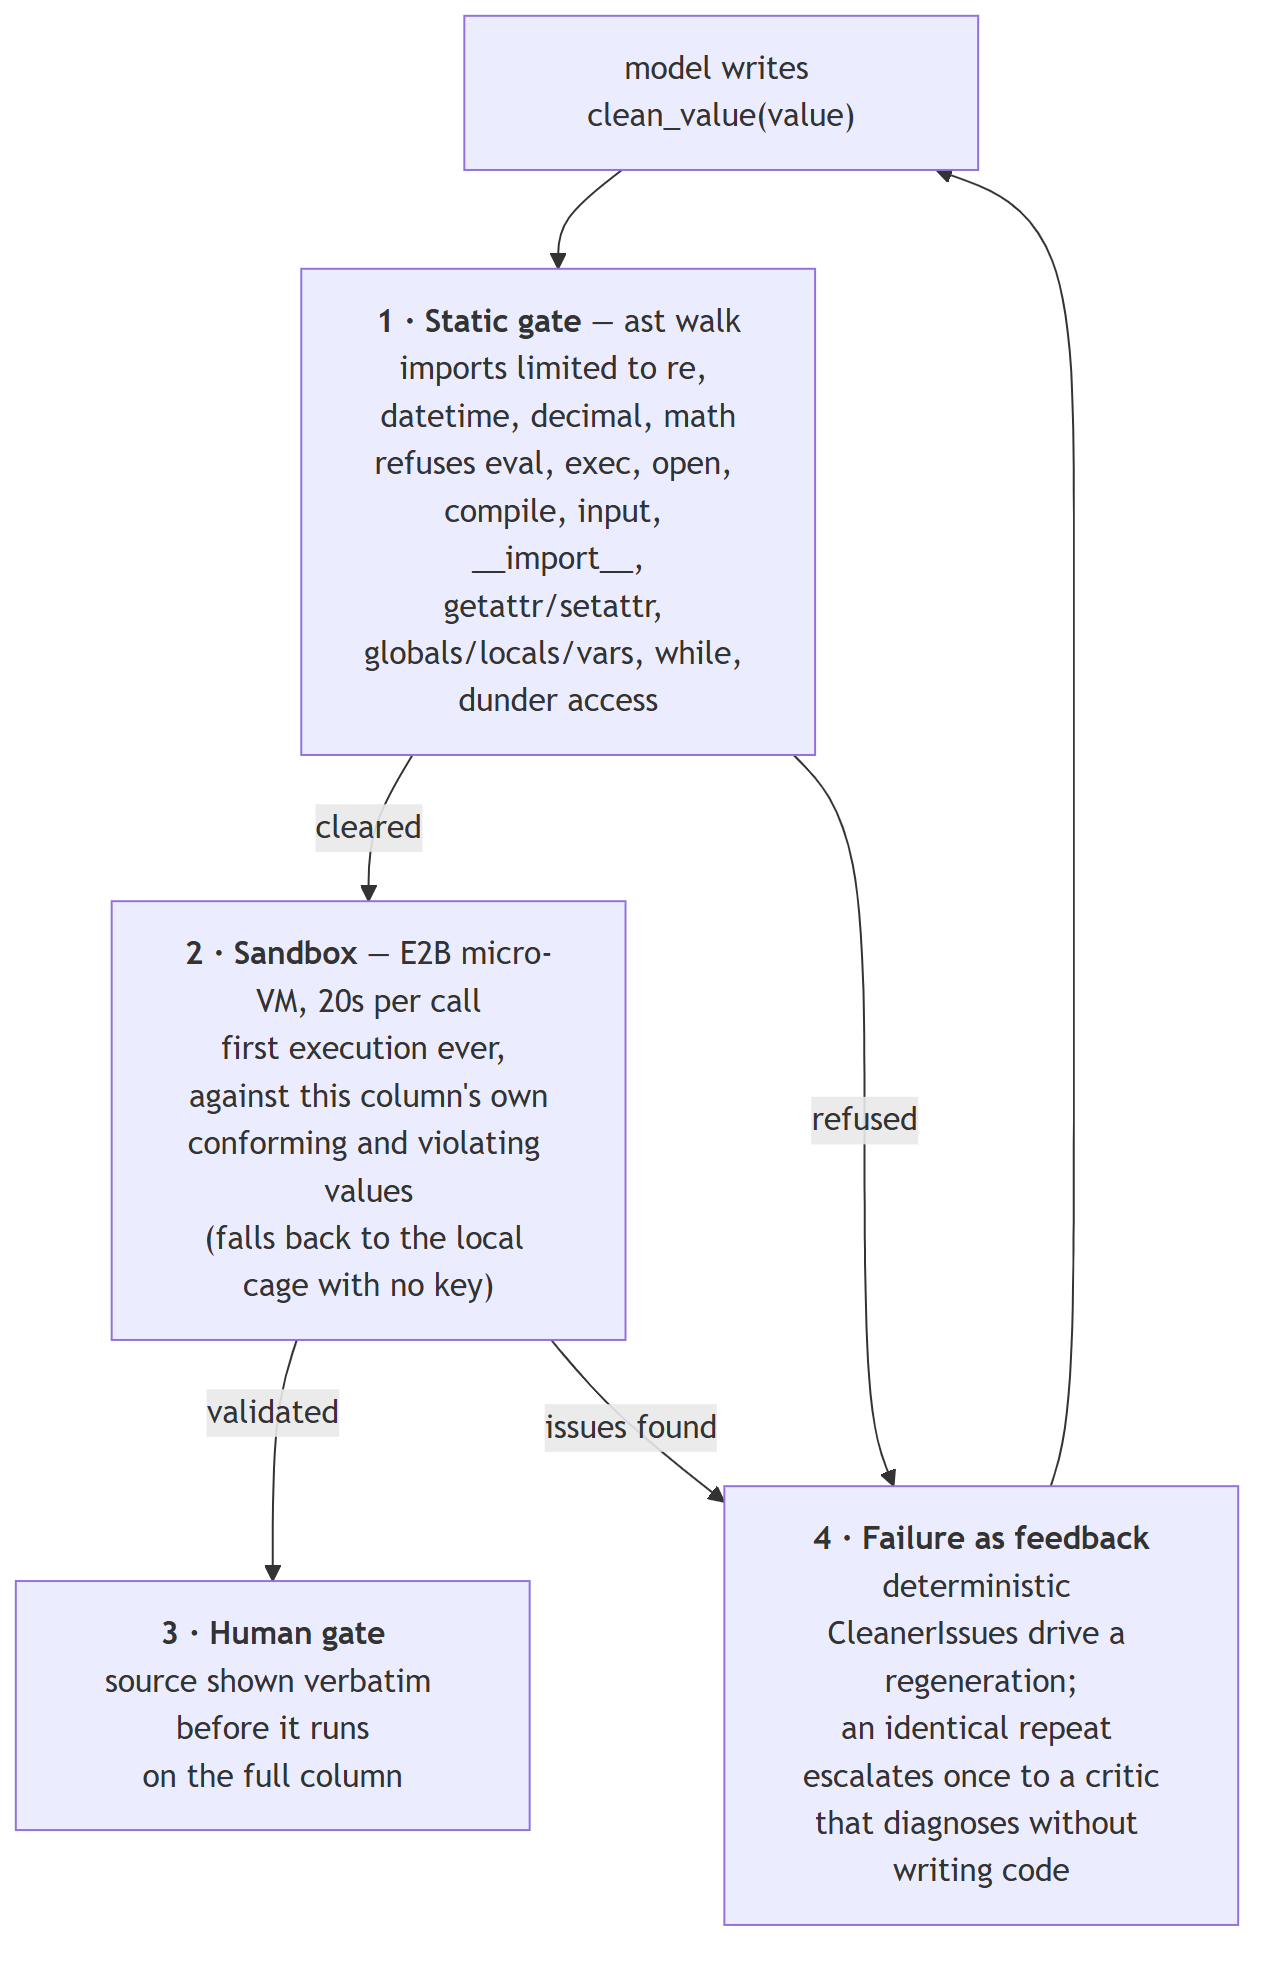

<!-- Diagram source (mermaid), rendered to the image above so it displays in every viewer.
Regenerate with:  npx @mermaid-js/mermaid-cli -i diagram.mmd -o diagram.png -b white -s 2

flowchart TB
  GEN["model writes clean_value(value)"] --> GATE
  GATE["<b>1 · Static gate</b> — ast walk<br/>imports limited to re, datetime, decimal, math<br/>refuses eval, exec, open, compile, input, __import__,<br/>getattr/setattr, globals/locals/vars, while, dunder access"]
  GATE -->|cleared| SBX
  GATE -->|refused| FEED
  SBX["<b>2 · Sandbox</b> — E2B micro-VM, 20s per call<br/>first execution ever, against this column's own<br/>conforming and violating values<br/>(falls back to the local cage with no key)"]
  SBX -->|validated| HUM
  SBX -->|issues found| FEED
  HUM["<b>3 · Human gate</b><br/>source shown verbatim before it runs<br/>on the full column"]
  FEED["<b>4 · Failure as feedback</b><br/>deterministic CleanerIssues drive a regeneration;<br/>an identical repeat escalates once to a critic<br/>that diagnoses without writing code"]
  FEED --> GEN
-->

Each is taken in turn below: the static gate in 9.1 and 9.2, the sandbox that performs the first execution off this machine in 9.3, and the failure path that turns a rejection into evidence in 9.4. The human gate is Section 12.

### 9.1 The static gate

The allow-list and the deny-list are short enough to read in full, which is the point — a reviewer can hold the entire threat model in their head.

In [177]:
import noipa_dq.tools.generated_function as gf

print("imports allowed :", sorted(gf._ALLOWED_MODULES))
print()
print("names refused   :", sorted(gf._FORBIDDEN_NAMES))
print()
print("builtins exposed:", len(gf._SAFE_BUILTIN_NAMES), "->", ", ".join(gf._SAFE_BUILTIN_NAMES[:14]), "...")

imports allowed : ['datetime', 'decimal', 'math', 're']

names refused   : ['__import__', 'breakpoint', 'compile', 'delattr', 'eval', 'exec', 'exit', 'getattr', 'globals', 'help', 'input', 'locals', 'memoryview', 'open', 'quit', 'setattr', 'vars']

builtins exposed: 46 -> abs, all, any, bool, chr, dict, divmod, enumerate, filter, float, format, frozenset, hash, int ...


The two functions that enforce it. `check_source` parses the source and walks it; `_check_node` is the per-node rule deciding what a single construct is allowed to be.

In [178]:
show(gf.check_source)
show(gf._check_node)

```python
def check_source(source: str) -> list[CleanerIssue]:
    """Reads the source and reports every reason it must not run. An empty list is the only
    clearance to execute; callers re-run this immediately before execution rather than trusting
    a clearance obtained earlier."""
    try:
        tree = ast.parse(source)
    except SyntaxError as error:
        return [CleanerIssue(
            category="malformed_source",
            message=f"the source does not parse: {error}",
            expected_behavior="return a single valid Python function definition.",
        )]

    issues = _check_shape(tree)
    issues.extend(_check_constructs(tree))
    return issues
```

```python
def _check_node(node: ast.AST) -> list[CleanerIssue]:
    if isinstance(node, (ast.Import, ast.ImportFrom)):
        return _check_import(node)
    if isinstance(node, ast.While):
        return [_forbidden(
            "while loops are not available to a generated cleaner",
            "normalise a scalar with bounded control flow; iterate over a finite sequence.",
        )]
    if isinstance(node, ast.Attribute) and node.attr.startswith("__"):
        return [_forbidden(
            f"attribute {node.attr!r} reaches into the interpreter internals",
            "use the value's ordinary methods only.",
        )]
    if isinstance(node, ast.Name) and node.id in _FORBIDDEN_NAMES:
        return [_forbidden(
            f"{node.id!r} is not available to a generated cleaner",
            "transform the value with plain expressions and the allowed modules.",
        )]
    return []
```

### 9.2 The gate, demonstrated

The cells below run for real and cost nothing — `check_source` is pure AST analysis, with no model and no network. Each candidate is a plausible-looking cleaning function; the gate reads the source and returns typed `CleanerIssue` objects.

First, a function that does exactly what it should:

In [179]:
legitimate = """
def clean_value(value):
    import re
    text = str(value).strip()
    match = re.fullmatch(r"(\\d{4})[-/.](\\d{1,2})", text)
    if match:
        return f"{match.group(1)}{int(match.group(2)):02d}"
    return text
"""

issues = gf.check_source(legitimate)
print("issues:", issues or "none - the gate clears it")

issues: none - the gate clears it


Now four that must not run. None of these is contrived: exfiltration through an import, a shell-out through `eval`, a read of the host filesystem, and an unbounded loop.

In [180]:
candidates = {
    "exfiltrates a credential": """
def clean_value(value):
    import os
    return os.environ.get("DEEPSEEK_API_KEY", str(value))
""",
    "evaluates a string": """
def clean_value(value):
    return eval(str(value))
""",
    "opens a file": """
def clean_value(value):
    return open("/etc/passwd").read()
""",
    "loops without a bound": """
def clean_value(value):
    while True:
        value = str(value)
    return value
""",
}

for label, source in candidates.items():
    issues = gf.check_source(source)
    print(f"{label}:")
    for issue in issues:
        print(f"    [{issue.category}] {issue.message}")
    print()

exfiltrates a credential:
    [forbidden_construct] module 'os' is not available to a generated cleaner

evaluates a string:
    [forbidden_construct] 'eval' is not available to a generated cleaner

opens a file:
    [forbidden_construct] 'open' is not available to a generated cleaner

loops without a bound:
    [forbidden_construct] while loops are not available to a generated cleaner



Every one is refused before it is ever executed, and the refusal is a **typed finding**, not a raised exception. That distinction is what makes the fourth layer possible: an issue carries the offending construct and the expected behaviour, so it can be fed back to the generator as deterministic evidence for another attempt.

### 9.3 The sandbox — the first execution leaves this machine

The static gate reasons about *source*. Some intent only becomes visible when the code **runs**: a regex that backtracks catastrophically, a `decimal` context that raises, a transform that quietly returns `None` for every value it was supposed to repair. Finding that out requires executing the function — and executing it is precisely the risky act.

Our position is that **the first execution of model-written source does not belong on this machine**. This laptop holds the raw dataset, a `.env` with three API keys, the git history and the whole filesystem; the code about to run was written seconds ago by a language model, has never executed anywhere, and has been inspected only by a parser. So it runs somewhere else: [`e2b-code-interpreter`](https://e2b.dev/docs) starts a **cloud micro-VM** and the cleaner's first run happens inside it.

What crosses the boundary is deliberately narrow — the generated source, the values as a JSON literal, and one marker-prefixed line of results coming back. No dataframe, no file, no credential.

In [181]:
print("timeout:", gf._SANDBOX_TIMEOUT_SECONDS, "s | marker:", gf._SANDBOX_MARKER)
print()
print(gf._driver_script(legitimate, ["2024-3", "2024/07", None]))

timeout: 20 s | marker: <<CLEANER_RESULTS>>

import json

def clean_value(value):
    import re
    text = str(value).strip()
    match = re.fullmatch(r"(\d{4})[-/.](\d{1,2})", text)
    if match:
        return f"{match.group(1)}{int(match.group(2)):02d}"
    return text

_values = json.loads("[\"2024-3\", \"2024/07\", null]")
_results = []
for _value in _values:
    try:
        _cleaned = clean_value(_value)
    except Exception as _error:
        _results.append({'ok': False, 'error': type(_error).__name__ + ': ' + str(_error)})
        continue
    _results.append({'ok': True, 'value': None if _cleaned is None else str(_cleaned)})
print("<<CLEANER_RESULTS>>" + json.dumps(_results))



Two things about that script are the point.

**The sandbox is asked what happened, never whether it was acceptable.** It returns `{"ok": ..., "value": ...}` per input and nothing more. Whether a `dominant_example_value` was modified, an outlier left unchanged, or a result is unparseable as the target dtype is decided by `_judge`, deterministically, **here** — so the judgement of generated code never depends on a remote machine.

**The fallback is a real degradation, and the code says so.** `E2B_API_KEY` is optional: with no key, or when the sandbox call fails, `_execute` runs the cleaner in the *local cage* instead — `load_callable` behind whitelisted builtins and a restricted import hook, in this very process. That keeps the pipeline running offline, in CI and across the 349 tests, but it is a weaker guarantee. Every attempt is appended to an execution log, so a run can be audited rather than assumed.

In [182]:
show(gf._execute)
show(gf.close_sandbox)

```python
def _execute(source: str, values: list[str | None]) -> tuple[list[dict], str]:
    if os.getenv("E2B_API_KEY"):
        try:
            results = _run_in_sandbox(source, values)
            _executions.append({"executor": "e2b", "ok": True, "values": len(values)})
            return results, "e2b"
        except Exception as error:
            _executions.append({"executor": "e2b", "ok": False, "detail": str(error)[:200]})
    results = _run_locally(source, values)
    _executions.append({"executor": "local", "ok": True, "values": len(values)})
    return results, "local"
```

```python
def close_sandbox() -> None:
    """Releases the sandbox held open across a run. A caller that opens one owns closing it: the
    handle survives the call that created it, so in a long-lived process such as the Streamlit
    gate an unclosed sandbox stays billed and connected for the whole session."""
    _discard_sandbox()
```

One sandbox is held open for a **whole run** and reused, because the repair loop re-checks a proposal at the top of every iteration and again when it settles — a fresh VM per check would cross the network dozens of times for the same source. Results are additionally cached by `(source, values)`, which is sound exactly because a cleaner is a pure scalar function. The handle outlives the call that created it, so `agents/unified.py` calls `close_sandbox()` at the end: in a long-lived process such as the Streamlit gate, an unclosed sandbox stays connected and billed for the entire session.

The log turns all of this into a fact about each run rather than a claim about the architecture.

In [183]:
RECORDED_RUNS = {
    "spesa (required)": ROOT / "reports" / "runs" / "spesa",
    "attivazioniCessazioni (required)": ROOT / "reports" / "runs" / "attivazioniCessazioni",
    "ritenuteSindacali (not developed against)": ROOT / "reports" / "runs" / "ritenuteSindacali",
}

runs_log = {
    label: figures.load_run(directory)[0].get("generated_function_runs") or []
    for label, directory in RECORDED_RUNS.items()
}

display(pd.DataFrame([{
    "run": label,
    "trials": len(entries),
    "in the E2B sandbox": sum(1 for e in entries if e["executor"] == "e2b" and e["ok"]),
    "sandbox attempts failed": sum(1 for e in entries if e["executor"] == "e2b" and not e["ok"]),
    "in the local cage": sum(1 for e in entries if e["executor"] == "local"),
} for label, entries in runs_log.items()]))

failed = [e for entries in runs_log.values() for e in entries if not e["ok"]]
print(f"\nsandbox attempts that fell back to the local cage: {len(failed)}")
if failed:
    print(" ", failed[0]["detail"][:150])

,run,trials,in the E2B sandbox,sandbox attempts failed,in the local cage
0,spesa (required),0,0,0,0
1,attivazioniCessazioni (required),6,6,0,0
2,ritenuteSindacali (not developed against),2,2,0,0



sandbox attempts that fell back to the local cage: 0


Read the three runs together and the layer stops being decorative. The `spesa` run shown throughout
this notebook produced no generated cleaner at all, so it has nothing to log — its repairs went
through auto-remediation and the typed catalogue. On the other two, **every first execution happened
off this machine**: six trials on `attivazioniCessazioni`, two on `ritenuteSindacali`, eight of eight
in the sandbox, none in the local cage.

That table used to read differently, and the reason is worth keeping. An earlier recording of
`attivazioniCessazioni` logged ten of twenty trials in the sandbox and the other ten locally — the
flip side of holding one VM open for a whole run. `Sandbox.create()` was called with no explicit
lifetime, the provider's default expired part-way through a ten-minute run, and every later trial
fell back to the host without anything failing. The fix is in `_open_sandbox`: an explicit lifetime
sized for a run, and a vanished VM reopened rather than conceded. What made it findable is that the
layer reports itself per trial — a guarantee that can degrade silently is the one that has to be
logged.

And the honest boundary, because a project of this sort usually glosses over it: **the sandbox
isolates the host, it does not restrain the code.** Inside the VM, the refused source from 9.2 would
run happily. The static gate is what makes execution on the full column safe; the sandbox is what
makes the *first* execution safe to attempt at all. Neither substitutes for the other.

### 9.4 Failure as feedback

A failed generation is not discarded and retried against the same prompt — that reliably produces the same failure. Each failure becomes typed `CleanerIssue` objects naming the offending input, the actual output and the expected behaviour.

The categories are the vocabulary the generator is corrected in. `dominant_value_modified` is the most important of them: it fires when a function rewrites a value that was already correct, which is worse than failing to fix a bad one.

In [184]:
from noipa_dq.models import CleanerIssue, CleanerIssueCategory, CleanerDiagnosis
show_file("src/noipa_dq/models.py", 155, 186)

```python
CleanerIssueCategory = Literal[
    "malformed_source",
    "forbidden_construct",
    "runtime_exception",
    "dominant_value_modified",
    "outlier_unchanged",
    "not_parseable_as_target_dtype",
    "not_validated",
]


class CleanerIssue(BaseModel):
    category: CleanerIssueCategory
    message: str
    input_value: str | None = None
    actual_output: str | None = None
    expected_behavior: str = ""


class CleanerRepair(BaseModel):
    input_value: str
    actual_output: str | None = None
    expected_output: str | None = None
    fix_note: str


class CleanerDiagnosis(BaseModel):
    root_cause: str
    bug_location: str
    planned_fix: str
    exact_repairs: list[CleanerRepair] = Field(default_factory=list)
    confidence: Literal["low", "medium", "high"] = "medium"
```

A failure that repeats **identically** escalates once to a critic model, on the reasoning that a model repeating itself needs a different question rather than another attempt. The critic diagnoses and prescribes; it never writes code.

In [185]:
show_markdown("src/noipa_dq/prompts/cleaner_critic.md", until="## Two failures that repeat")

# Cleaner Repair Critic Prompt

You diagnose a cleaning function that failed validation twice in the same way. The deterministic
feedback already given to the generator did not unblock it, which is why you were called.

You do not write code. You explain what is wrong and prescribe the repair, precisely enough that
the next attempt is a different attempt rather than the same one again.

## Input

- `column`: the column the function cleans.
- `source`: the function that failed.
- `issues`: the authoritative validation findings. Each carries a `category`, the `input_value`
  that produced it, the `actual_output` the function returned, and the `expected_behavior`.
- `dominant_example_values`: values that already conform. The function must return these unchanged.
- `example_inconsistent_values`: values that violate the format. The function must transform them.

## The issue categories, and what each one means

- `dominant_value_modified` - the function rewrote a value that was already correct. This is
  almost always a branch written for a malformed layout that fires on a well-formed one, because
  the already-valid guard is missing, is too narrow, or sits below that branch. Prioritise this
  over everything else: breaking good data is worse than failing to fix bad data.
- `outlier_unchanged` - a malformed value fell through every branch and was returned as-is. Either
  no branch matches its shape, or an earlier branch consumed it and returned it untouched.
- `not_parseable_as_target_dtype` - the transformation ran but produced something the column
  cannot hold. Usually a leftover symbol, a unit, or components emitted in the wrong order.
- `runtime_exception` - the function raised. Name the operation that raised and the input shape
  that reaches it.

*[...]*

## 10. Invariants: rules that are executed, not stated

`tools/fix_invariants.py` evaluates the before/after dataframes of **every** proposal and refuses it if it breaks any of five rules.

This file exists because of a specific bug. An imputation was once proposed on a column that was **98.5% empty**. The rule had been stated in the prompt, and the model ignored it — unnoticed, because nothing checked. The principle we drew from it now governs the codebase: **a rule that can be checked by executing the fix belongs in code, not in a prompt.**

In [186]:
import noipa_dq.tools.fix_invariants as inv
show(inv.check_invariants)
print("max deletion ratio      :", inv._MAX_DELETION_RATIO)
print("max fillable missing rate:", inv._MAX_FILLABLE_MISSING_RATE)

```python
def check_invariants(
    before: pd.DataFrame,
    after: pd.DataFrame,
    proposal,
    imputation_hints: dict | None = None,
    removable_by_column: dict[str, set] | None = None,
) -> list[str]:
    hints = imputation_hints or {}
    removable = removable_by_column or {}
    failures: list[str] = []
    failures.extend(_check_row_count(before, after, proposal))
    for column in after.columns:
        if column not in before.columns:
            continue
        failures.extend(_check_invented_values(before[column], after[column], column, hints))
        failures.extend(_check_deleted_values(before[column], after[column], column, removable))
        failures.extend(_check_casing_split(before[column], after[column], column))
    return failures
```

max deletion ratio      : 0.02
max fillable missing rate: 0.5


### 10.1 The sparsity invariant, demonstrated

The bug that motivated the file, reproduced. A column 98% empty, and a fix that fills it — the sort of proposal that looks helpful and is not.

In [187]:
from noipa_dq.models import FixProposal, Operation

sparse_before = pd.DataFrame({"note": [None] * 98 + ["archived", "manual"]})
sparse_after = sparse_before.copy()
sparse_after["note"] = sparse_after["note"].fillna("archived")

proposal = FixProposal(
    id="fill_note", description="Fill the empty notes", rationale="looks helpful",
    operations=[Operation(kind="replace_values", column="note")],
)

for failure in inv.check_invariants(sparse_before, sparse_after, proposal):
    print(failure)

note: 98 missing values were filled, but the column was 98.0% empty before the fix. A column this sparse can only be flagged or dropped, because what little it holds cannot speak for what it does not.


The invariant states the reason in the refusal itself: *what little such a column holds cannot speak for what it does not*. The proposal never reaches the reviewer.

### 10.2 Inventing data, demonstrated

The same guard from the other direction: filling gaps with no mined dependency behind them. Without an `ImputationHint`, a fill is a guess, however plausible the value.

In [188]:
guess_before = pd.DataFrame({"area_geografica": ["Nord", None, "Centro", None, "Sud", "Nord"]})
guess_after = guess_before.copy()
guess_after["area_geografica"] = guess_after["area_geografica"].fillna("Nord")

guess = FixProposal(
    id="fill_area", description="Fill the missing macro-areas", rationale="Nord is most frequent",
    operations=[Operation(kind="replace_values", column="area_geografica")],
)

print("without an imputation hint:")
for failure in inv.check_invariants(guess_before, guess_after, guess):
    print("   ", failure)

hint = {"area_geografica": {"predictor_columns": ["ente"], "purity": 1.0}}
print("\nwith a mined dependency backing it:")
print("   ", inv.check_invariants(guess_before, guess_after, guess, imputation_hints=hint) or "accepted")

without an imputation hint:
    area_geografica: 2 missing values were filled without an imputation hint

with a mined dependency backing it:
    accepted


The same fill is refused as a guess and accepted as a deduction. Nothing about the *values* changed between the two calls — what changed is whether the pipeline had measured evidence that the value was determined. That is the division of authority made executable.

## 11. The end-to-end run

With `LIVE_RUN = False` the artefacts of a completed run are loaded and nothing executes. With
`LIVE_RUN = True` the same twelve nodes run in order against `spesa.csv`, each timed, and write
those same artefacts into `reports/runs/spesa/` — so everything below this cell reads one freshly written
record either way.

The live path is `record_run.py`, the tracked recorder that produced the artefacts committed to this
repository. It is shown rather than restated: the twelve nodes, the gate between the ninth and the
tenth, and the per-stage clock are all in it.

One thing it does that a reviewer would not: it **approves every proposal**. A notebook has nowhere
to put a human decision, so the recorded run takes the upper bound on what the system will do. The
Streamlit application is where each proposal is actually accepted, rejected or sent back.

In [189]:
import record_run

show(record_run.record)

```python
def record(source: Path, out_dir: Path) -> dict[str, float]:
    out_dir.mkdir(parents=True, exist_ok=True)
    working = out_dir / source.name
    shutil.copy2(source, working)

    state = PipelineState(dataset=pd.read_csv(working), dataset_path=str(working))
    timings: dict[str, float] = {}

    for label, node in DETECTION_NODES:
        state = _timed(label, node, state, timings)

    approved = [proposal.id for proposal in state.proposed_fixes]
    print(f"gate: approving {len(approved)} of {len(state.proposed_fixes)} proposals", flush=True)
    state = state.model_copy(update={"approved_fix_ids": approved})

    for label, node in DELIVERY_NODES:
        state = _timed(label, node, state, timings)

    (out_dir / "timings.json").write_text(
        json.dumps(timings, indent=2), encoding="utf-8"
    )
    print(f"recorded {source.stem} in {sum(timings.values()):.1f}s -> {out_dir}", flush=True)
    if state.errors:
        print("errors:", state.errors, flush=True)
    return timings
```

Whichever mode ran, the factual record is the report payload the run wrote. Every figure in the rest of this notebook is read from it, never recomputed by hand — a number here cannot disagree with the number in the delivered report.

In [190]:
if LIVE_RUN:
    timings = record_run.record(DATASET, RUN_DIR)
else:
    timings = json.loads((RUN_DIR / "timings.json").read_text(encoding="utf-8"))
    print("replaying the recorded run from", RUN_DIR.relative_to(ROOT))

report = json.loads(REPORT_JSON.read_text(encoding="utf-8"))

print()
print("dataset :", Path(report["dataset_path"]).name)
print("domain  :", report["detected_domain"], "| language:", report["detected_language"])
print("shape   :", report["shape"])
print("errors  :", report["errors"] or "none")

replaying the recorded run from reports\runs\spesa

dataset : spesa.csv
domain  : Trattamento_economico | language: it
shape   : {'rows': 7478, 'columns': 11}
errors  : none


### 11.1 Where the time goes

The cost profile is the architecture made visible. The stages that *reason* are expensive; the stages that *measure and act* are effectively free — and, as Section 12 shows, the cheap ones do the overwhelming majority of the work.

In [191]:
llm_stages = {"profiler", "semantic", "duplicate_column",
              "anomaly_detector", "unified", "report_generator"}
rows = [{"stage": stage,
         "seconds": seconds,
         "calls a model": "via tools" if stage == "format_consistency"
                          else ("yes" if stage in llm_stages else "-")}
        for stage, seconds in sorted(timings.items(), key=lambda kv: -kv[1])]
frame = pd.DataFrame(rows)
print(f"total {sum(timings.values()):.1f}s\n")
frame

total 659.1s



,stage,seconds,calls a model
0,unified,361.24,yes
1,format_consistency,84.24,via tools
2,semantic,72.48,yes
3,apply_fixes,42.50,-
4,auto_remediation,36.81,-
5,report_generator,35.79,yes
6,duplicate_column,9.83,yes
7,profiler,7.58,yes
8,anomaly_detector,6.21,yes
9,baseline_builder,1.01,-


The same figures as a chart. Each bar is one stage of the run, and the dark bars are the stages that call a model: they dominate the total, while the stages that measure and act sit near zero.

**The totals are one measurement, not a property of the system.** All three runs were recorded a second time on a quiet machine and every one came in faster — `spesa` 659.1s → 431.3s, `attivazioniCessazioni` 628.2s → 437.1s, `ritenuteSindacali` 523.0s → 255.3s — while changing the same cells to the same scores. The two halves of the chart move for different reasons. The model-calling stages went both ways (`unified` fell on `spesa`, rose on the other two): that is provider latency. The deterministic stages fell by an order of magnitude on all three files at once (`apply_fixes` 42.5s → 3.1s, `auto_remediation` 36.8s → 2.5s) — no network is involved there, so that gap is load on the recording machine rather than the pipeline. It leaves the shape of the chart intact and makes it steeper: on the second recording the cheap stages that change 92% of the cells cost 2.7 seconds out of 431. Section 4.6 of the README reads the two recordings side by side; the second is kept in `reports/runs/second_pass_timings.json`.


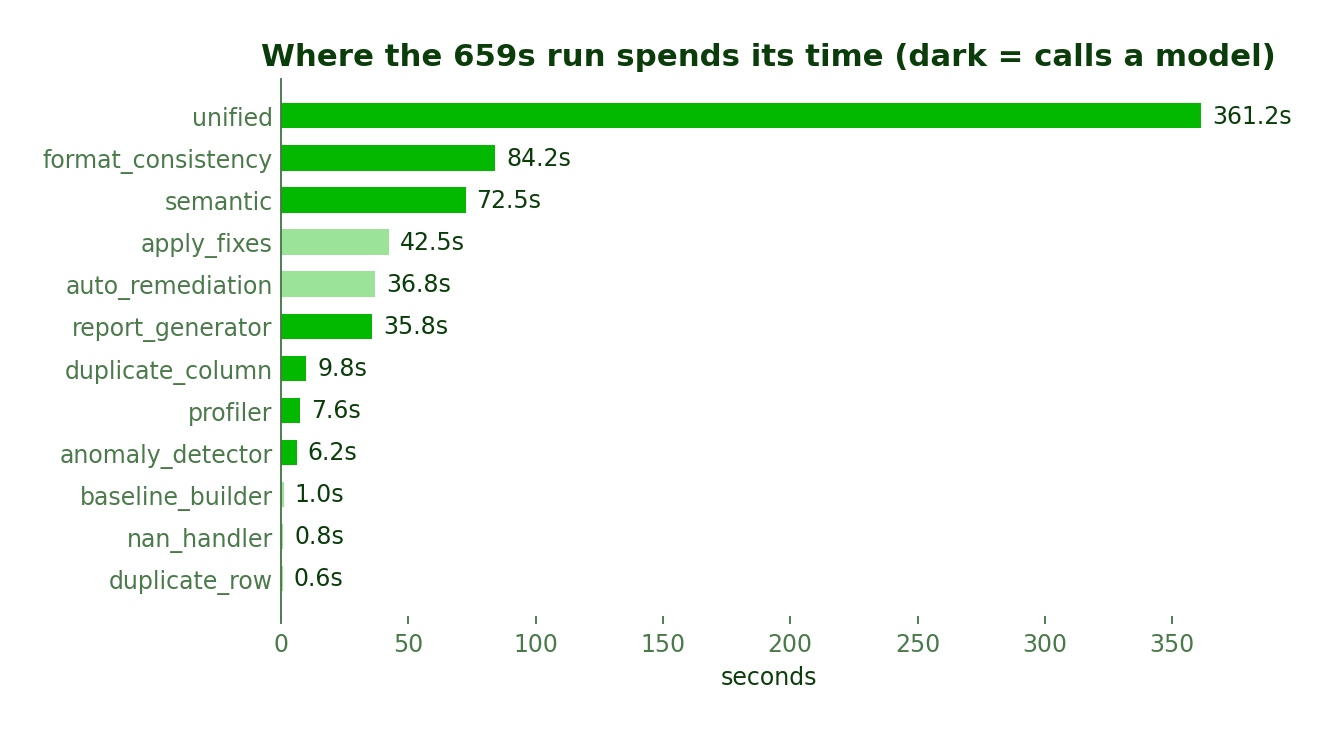

In [192]:
display(Image(figures.to_png(figures.stage_timings(timings))))

### 11.2 What detection found

Violations are counted by the `kind` each one carries, so the five coverage areas of the brief are reported separately rather than as one undifferentiated total.

**Uniqueness counts rows, not reports.** Nothing in the pipeline files an exact duplicate row as a violation, so counting the validation reports alone described a file that arrived with forty of them as having had no uniqueness defect at all — while the uniqueness dimension of the score was being marked down for exactly those rows. The tally now counts what the dimension penalises: every row that is either an exact duplicate or locked in a key collision.

In [193]:
detected = report["violations_by_kind_detected"]
residual = report["violations_by_kind_residual"]
pd.DataFrame({"detected": detected, "still standing after remediation": residual})

,detected,still standing after remediation
format,513,0
completeness,17337,1633
schema,5,0
consistency,517,0
uniqueness,87,0


Detected against residual, by coverage area, on a log scale so the four orders of magnitude between completeness and schema stay readable in one frame. Only completeness has anything left standing.

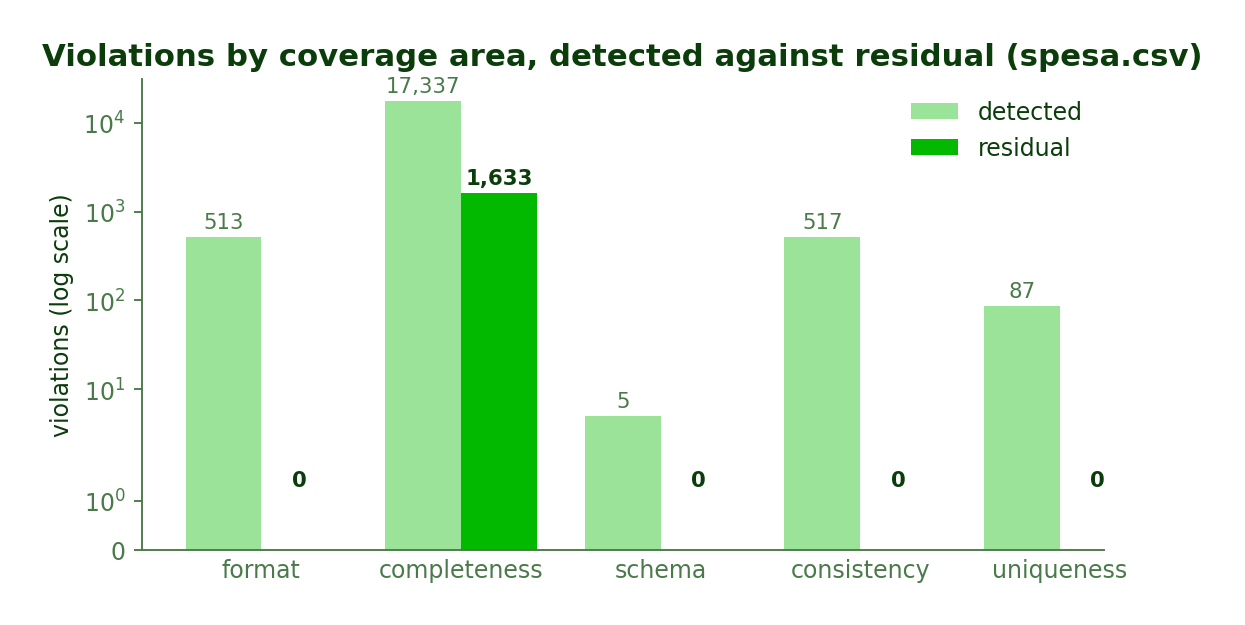

In [194]:
display(Image(figures.to_png(figures.violations_by_area(report))))

### 11.3 Disguised nulls

This is the measurement that no naive check makes, and it is why the pipeline records quality at **three** points rather than two.

In [195]:
hidden = report["quality"]["hidden_defects_unmasked"]
print(f"disguised nulls unmasked : {hidden['disguised_nulls_unmasked']:,}")
print(f"apparent completeness    : {hidden['apparent_completeness']}")
print(f"true completeness        : {hidden['true_completeness']}")
print()
print("Unmasking a hidden null makes measured completeness go DOWN. Nothing was lost:")
print("the second figure is the first honest measurement of the file.")

disguised nulls unmasked : 988
apparent completeness    : 0.8752
true completeness        : 0.868

Unmasking a hidden null makes measured completeness go DOWN. Nothing was lost:
the second figure is the first honest measurement of the file.


### 11.4 What the data determined on its own

Applied before the gate, because none of these required a *choice*.

In [196]:
pd.DataFrame(report["auto_remediations"])

,column,operation,cells_changed,rationale,predictor_columns,purity,cells_still_missing
0,rata,normalize_period,414,alternative period layouts rewritten to the ca...,NaN,NaN,NaN
1,spesa,round_decimals,2878,the column is recorded at 2 decimals; the extr...,NaN,NaN,NaN
2,rata,complete_period_from_dependency,96,values naming only a year were completed from ...,NaN,NaN,NaN
3,descrizione,impute_from_lookup,448,"ente -> descrizione: purity=0.99, coverage=0.9...",[ente],0.9928,8.0
4,imposta,impute_from_lookup,379,"cod_imposta -> imposta: purity=1.00, coverage=...",[cod_imposta],0.9994,0.0


## 12. The human approval gate

This is the point of the architecture. `apply_fixes` executes **only** the ids in `state.approved_fix_ids`; with an empty list it is a no-op, and there is no other route from a proposal to the dataset.

The recorded run this notebook replays approves **all** of them: with no reviewer at the keyboard it takes the upper bound on what the system will do, which is what makes the delta below measurable. The point of the gate is that a reviewer can decline any of it.

Below are the proposals the Unified agent put to a reviewer. In the Streamlit application (`streamlit run app/streamlit_app.py`) each is rendered with the code it carries and three buttons — **Accept**, **Reject**, **Revise** — where Revise sends natural-language feedback back to the agent and re-proposes that group alone. Where the repair is a typed catalogue operation the gate shows the equivalent pandas expression and says it is an illustration; where the model wrote a `clean_value` function it shows that source verbatim and says it is what will run. None of the six proposals below carried generated code.

In [197]:
for proposal in report["proposed_remediations"]:
    print(f"[{proposal['id']}]  approved={proposal.get('applied')}")
    print(f"   {proposal['description']}")
    print(f"   affects {proposal.get('affected_columns')} · ~{proposal.get('estimated_rows_affected', 0):,} row(s)")
    print(f"   rationale: {textwrap.shorten(proposal['rationale'], 200)}")
    for operation in proposal.get("operations", []):
        print(f"   -> {operation}")
    print()

[schema_drop_note]  approved=True
   Drop 'note': it is 98.0% null and carries almost no information.
   affects ['note'] · ~7,393 row(s)
   rationale: 7393 of its cells are empty. Removing the column is a schema decision, so it is proposed rather than applied.
   -> drop_column on note

[schema_drop_fonte_dato]  approved=True
   Drop 'fonte_dato': it is 99.0% null and carries almost no information.
   affects ['fonte_dato'] · ~7,468 row(s)
   rationale: 7468 of its cells are empty. Removing the column is a schema decision, so it is proposed rather than applied.
   -> drop_column on fonte_dato

[schema_rename__id]  approved=True
   Rename '_id' to 'id' to match the naming convention.
   affects ['_id'] · ~0 row(s)
   rationale: The column name breaks the convention declared in the baseline. Renaming changes the schema, so it is proposed rather than applied.
   -> rename_column _id to id

[schema_rename_aggregation-time]  approved=True
   Rename 'aggregation-time' to 'aggregation_time' 

Notice the naming. A proposal is named for **what it does** — `schema_drop_note`, `rename_column`, `clean_<column>` — whether it was written deterministically or by the model, so a reviewer reads an action rather than a token.

The reviewer's decision is the whole of the input to execution:

In [198]:
approved = [p["id"] for p in report["proposed_remediations"] if p.get("applied")]
print("approved_fix_ids =", approved)
print()
print("applied          =", report["applied_fix_ids"])
print("refused / errored=", report["errors"] or "none")

approved_fix_ids = ['schema_drop_note', 'schema_drop_fonte_dato', 'schema_rename__id', 'schema_rename_aggregation-time', 'impute_from_lookup_descrizione', 'replace_values_imposta']

applied          = ['schema_drop_note', 'schema_drop_fonte_dato', 'schema_rename__id', 'schema_rename_aggregation-time', 'replace_values_imposta', 'impute_from_lookup_descrizione']
refused / errored= none


Every approved id that did **not** land is surfaced too — whether it errored, breached an invariant, or was skipped — so a silent partial application is impossible.

### 12.1 What actually changed, and on whose authority

The change log records every modified cell with the stage responsible. This single table is the clearest statement of the division of authority in the whole project.

In [199]:
by_source = report["changes_summary"]["by_source"]
total = report["changes_summary"]["total_cells_changed"]
frame = pd.DataFrame(
    [{"source": k, "cells changed": v, "share": f"{v / total:.1%}"} for k, v in by_source.items()]
).sort_values("cells changed", ascending=False)
print(f"{total:,} cells changed in total\n")
frame

5,659 cells changed in total



,source,cells changed,share
0,auto_remediation,4215,74.5%
1,nan_handler:placeholders,988,17.5%
2,duplicate_column,424,7.5%
3,collapse_casing,22,0.4%
4,nan_handler:dtype,4,0.1%
5,replace_values_imposta,4,0.1%
6,duplicate_column:dtype,2,0.0%


The same split as a chart. Each bar is the number of cells one stage changed, and the ordering carries the point of the section: the deterministic stages moved almost everything, the approved proposals almost nothing.

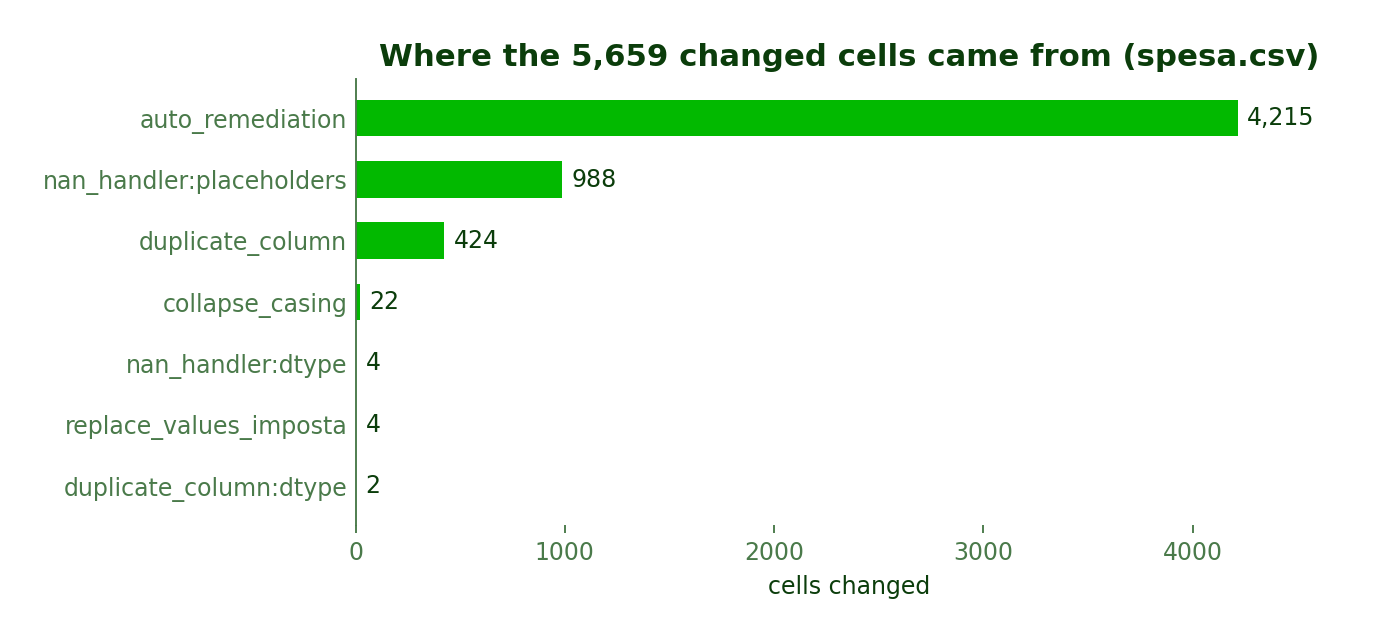

In [200]:
display(Image(figures.to_png(figures.cells_changed_by_source(report))))

The deterministic stages moved almost every value; the human decided which **columns should exist**. Those are different kinds of decision, and the system keeps them apart.

### 12.2 Issues carried without a corrective action

A defect with no honest repair is reported as such, with the reason. This is the outcome the `UnaddressedViolations` contract of Section 5.6 exists to make possible.

In [201]:
for entry in report["unaddressed_violations"]:
    print("columns:", entry["columns"])
    print("rows   :", entry.get("affected_by_column"))
    print("reason :", textwrap.fill(entry["reason"], 100, subsequent_indent="         "))
    print()

columns: ['cod_tipoimposta', 'area_geografica', 'tipo_imposta', 'spesa', 'cod_imposta']
rows   : {'cod_tipoimposta': 1, 'area_geografica': 1582, 'tipo_imposta': 384, 'spesa': 59, 'cod_imposta': 1}
reason : The missing values in area_geografica (1582), note (7393), fonte_dato (7468), and spesa (59) cannot
         be safely filled: none of these columns has an imputation hint, and filling them would
         require inventing data or applying a statistic without a deterministic rule.
         area_geografica, note, and fonte_dato have no predictor columns in the group, and spesa is
         a monetary amount that must not be imputed without an explicit user-provided rule. These
         require human judgement.



## 13. The reliability score

The score is published **twice**, and the second number is the honest one.

**As delivered** compares only the dimensions measurable on the raw file. *Validity* and *consistency* cannot be scored before the pipeline has inferred a format spec and mined the cross-column rules to score them against — so a run that quoted only this figure would be taking credit for the arrival of its own measuring instruments.

**Like-for-like** scores both ends over the same five dimensions, using the pre-remediation snapshot taken once those specs exist. It is the smaller improvement and the one to trust.

In [202]:
quality = report["quality"]
for label in ("as_delivered", "like_for_like"):
    block = quality[label]
    print(f"{label}: {block['before']['score']:.4f} -> {block['after']['score']:.4f}"
          f"   over {len(block['dimensions'])} dimensions")
print()
print("dimensions excluded from the as-delivered comparison:", quality["dimensions_excluded"])

as_delivered: 0.7562 -> 0.9933   over 3 dimensions
like_for_like: 0.9380 -> 0.9960   over 5 dimensions

dimensions excluded from the as-delivered comparison: ['validity', 'consistency']


Broken down by dimension, so the aggregate above can be read as the sum of its parts. `delta` is the movement each dimension contributed.

In [203]:
ll = quality["like_for_like"]
pd.DataFrame({
    "before": ll["before"]["components"],
    "after": ll["after"]["components"],
}).assign(delta=lambda d: (d["after"] - d["before"]).round(4))

,before,after,delta
completeness,0.9702,0.9801,0.0099
validity,0.9930,1.0000,0.0070
consistency,0.9319,1.0000,0.0681
uniqueness,0.9885,1.0000,0.0115
schema_conformity,0.8182,1.0000,0.1818


The same five dimensions as a chart, before and after remediation. Schema conformity moves furthest and completeness least, and the last bar is the one Section 13.1 explains.

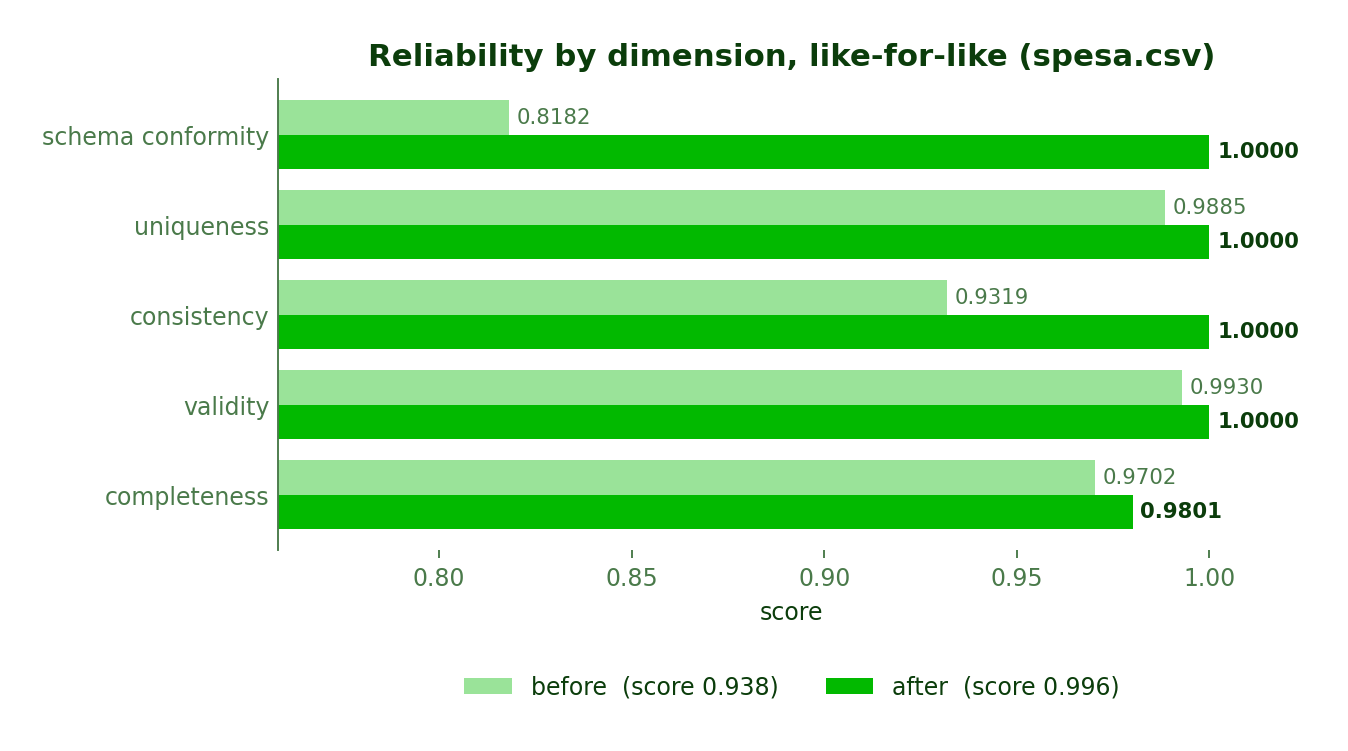

In [204]:
display(Image(figures.to_png(figures.reliability_dimensions(report))))

### 13.1 The three snapshots

Quality is measured at the raw file, once disguised nulls are unmasked, and as delivered — precisely so that *discovering* a hidden gap is never mistaken for *creating* one.

In [205]:
snapshots = quality["snapshots"]
keys = ["rows", "columns", "null_cells", "duplicate_rows", "completeness",
        "uniqueness", "schema_conformity"]
pd.DataFrame({
    name: {k: snapshots[name].get(k) for k in keys}
    for name in ("raw", "detected", "final") if name in snapshots
})

,raw,detected,final
rows,7543.0000,7543.0000,7478.0000
columns,18.0000,18.0000,11.0000
null_cells,16939.0000,17927.0000,1633.0000
duplicate_rows,40.0000,40.0000,0.0000
completeness,0.8752,0.8680,0.9801
uniqueness,0.9881,0.9947,1.0000
schema_conformity,0.5000,0.5000,1.0000


Completeness at the three measurement points. The middle bar is *lower* than the first, and the annotation says why: unmasking a disguised null makes the measurement honest, not worse.

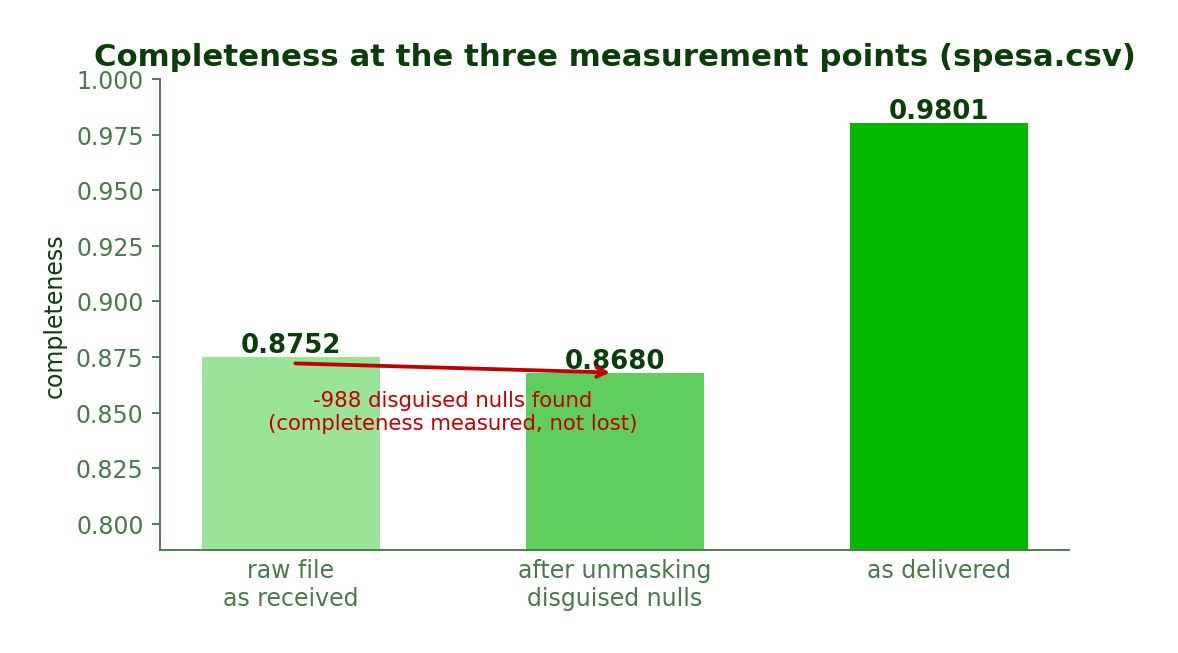

In [206]:
display(Image(figures.to_png(figures.completeness_journey(report))))

## 14. The delivered report

`report_generator` assembles a fully deterministic payload — every count, table and chart — and only then calls the model, asking it **exclusively** for the interpretation: the verdict, one comment per coverage area, and the recommendations. A wrong number cannot enter the document through a sentence, because sentences are not where numbers come from.

In [207]:
narrative = report["narrative"]
for section, text in narrative.items():
    print(f"### {section}")
    print(textwrap.fill(str(text), 100) if isinstance(text, str) else text)
    print()

### verdict
This is a NoiPA payroll expenditure dataset covering tax and deduction amounts across Italian public
administrations. After remediation it is in good, usable shape: structural defects are gone,
consistency and uniqueness are fully resolved, and the only remaining weakness is a genuine gap in
the area_geografica field. The dataset is clean enough for analysis, with the geographic coverage
gap being the one issue that still needs attention at the source.

### schema_comment
The raw file carried seven badly named columns, two near-empty columns (note and fonte_dato, at
roughly 98% and 99% null), and a redundant tax-code column, all of which have now been renamed,
dropped, or consolidated. The duplicate-column groups were the most consequential: tipo_imposta and
spesa each existed twice under different names, and the surviving versions disagreed with the
dropped ones on hundreds of cells. These naming and duplication problems are worth fixing at the
source so each field is expo

The document itself is written as Markdown, HTML and PDF beside the cleaned dataset and the cell-level change log. Rendered here in full:

In [208]:
display(Markdown((RUN_DIR / "spesa.md").read_text(encoding="utf-8")))

# Data Quality Report - spesa.csv

<sub>Generated 2026-09-02 20:08 | domain Trattamento_economico | language it</sub>

## Verdict

**Reliability 0.756 to 0.993** over completeness, uniqueness, schema_conformity. The score is a geometric mean, so one broken dimension pulls it down rather than being averaged away.
Not measurable on the file as delivered, and therefore outside this figure: validity, consistency.

<svg xmlns='http://www.w3.org/2000/svg' width='660' height='118' viewBox='0 0 660 118' font-family='Helvetica,Arial,sans-serif'><rect x='0' y='0' width='660' height='118' fill='#ffffff'/><text x='0' y='14' font-size='10.5' font-weight='bold' fill='#0b3d0b'>Quality dimensions, as delivered against remediated</text><rect x='470' y='7.0' width='9' height='7' fill='#9ae399'/><text x='483' y='14.0' font-size='7.5' fill='#4a7a4a'>as delivered</text><rect x='564' y='7.0' width='9' height='7' fill='#02b900'/><text x='577' y='14.0' font-size='7.5' fill='#4a7a4a'>after remediation</text><line x1='132.0' y1='18.0' x2='132.0' y2='106.0' stroke='#ccf1cc' stroke-width='1'/><text x='132.0' y='116.0' text-anchor='middle' font-size='7.5' fill='#4a7a4a'>0%</text><line x1='249.5' y1='18.0' x2='249.5' y2='106.0' stroke='#ccf1cc' stroke-width='1'/><text x='249.5' y='116.0' text-anchor='middle' font-size='7.5' fill='#4a7a4a'>25%</text><line x1='367.0' y1='18.0' x2='367.0' y2='106.0' stroke='#ccf1cc' stroke-width='1'/><text x='367.0' y='116.0' text-anchor='middle' font-size='7.5' fill='#4a7a4a'>50%</text><line x1='484.5' y1='18.0' x2='484.5' y2='106.0' stroke='#ccf1cc' stroke-width='1'/><text x='484.5' y='116.0' text-anchor='middle' font-size='7.5' fill='#4a7a4a'>75%</text><line x1='602.0' y1='18.0' x2='602.0' y2='106.0' stroke='#ccf1cc' stroke-width='1'/><text x='602.0' y='116.0' text-anchor='middle' font-size='7.5' fill='#4a7a4a'>100%</text><text x='126' y='35.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>completeness</text><rect x='132' y='25.0' width='411.3' height='9' fill='#9ae399' rx='1.5'/><rect x='132' y='36.0' width='460.6' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='38.0' text-anchor='end' font-size='8' fill='#0b3d0b'>0.875 to 0.980</text><text x='126' y='61.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>uniqueness</text><rect x='132' y='51.0' width='464.4' height='9' fill='#9ae399' rx='1.5'/><rect x='132' y='62.0' width='470.0' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='64.0' text-anchor='end' font-size='8' fill='#0b3d0b'>0.988 to 1.000</text><text x='126' y='87.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>schema conformity</text><rect x='132' y='77.0' width='235.0' height='9' fill='#9ae399' rx='1.5'/><rect x='132' y='88.0' width='470.0' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='90.0' text-anchor='end' font-size='8' fill='#0b3d0b'>0.500 to 1.000</text></svg>

This is a NoiPA payroll expenditure dataset covering tax and deduction amounts across Italian public administrations. After remediation it is in good, usable shape: structural defects are gone, consistency and uniqueness are fully resolved, and the only remaining weakness is a genuine gap in the area_geografica field. The dataset is clean enough for analysis, with the geographic coverage gap being the one issue that still needs attention at the source.

## The dataset as received

| measure | value |
|---|---|
| rows | 7,543 |
| columns | 18 |
| null cells | 16,939 |
| nulls disguised as values | 988 |
| duplicate rows | 40 |
| rows in key conflict | 50 |
| columns badly named | 7 |
| columns almost empty | 2 |
| columns duplicating another | 4 |
| columns still holding the wrong type | 0 |

Completeness read 87.5% on the file as delivered and 86.8% once the placeholders standing in for gaps were counted as gaps. The lower figure is the accurate one.

### What was wrong, by coverage area

| area | detected | for example |
|---|---|---|
| Schema validation | 2 names against convention, 5 schema violations | `_id`, `aggregation-time` |
| Completeness | 17,337 completeness violations | `n.d.`, `?`, `//` |
| Consistency | 517 cross-column violations, 4 duplicate column groups | `ente`, `tipo_imposta`, `cod_imposta` |
| Duplicate detection | 87 rows not unique when measured, 65 exact duplicates removed | - |
| Anomaly detection | 1354 across 2 columns | `imposta`, `spesa` |
| Format validity | 513 format violations | `descrizione`, `note`, `fonte_dato` |

## What the pipeline found

### Schema validation

| column | suggested name |
|---|---|
| `_id` | `id` |
| `aggregation-time` | `aggregation_time` |

| column too empty to inform | nulls | null rate |
|---|---|---|
| `note` | 7,393 | 98.0% |
| `fonte_dato` | 7,468 | 99.0% |

The raw file carried seven badly named columns, two near-empty columns (note and fonte_dato, at roughly 98% and 99% null), and a redundant tax-code column, all of which have now been renamed, dropped, or consolidated. The duplicate-column groups were the most consequential: tipo_imposta and spesa each existed twice under different names, and the surviving versions disagreed with the dropped ones on hundreds of cells. These naming and duplication problems are worth fixing at the source so each field is exported once, under one canonical name.

### Completeness

| measure | value |
|---|---|
| overall fill rate | 86.8% |
| null cells | 17,927 of 135,774 |
| rows with no gaps | 1 |
| rows carrying a gap | 7,542 |

These figures are measured once the placeholders standing in for gaps have been counted as gaps, so the null count is higher here than in the summary of the file as received, which reports what the file appeared to hold.

<svg xmlns='http://www.w3.org/2000/svg' width='660' height='292' viewBox='0 0 660 292' font-family='Helvetica,Arial,sans-serif'><rect x='0' y='0' width='660' height='292' fill='#ffffff'/><text x='0' y='14' font-size='10.5' font-weight='bold' fill='#0b3d0b'>Fill rate by column, least complete first</text><line x1='132.0' y1='18.0' x2='132.0' y2='280.0' stroke='#ccf1cc' stroke-width='1'/><text x='132.0' y='290.0' text-anchor='middle' font-size='7.5' fill='#4a7a4a'>0%</text><line x1='249.5' y1='18.0' x2='249.5' y2='280.0' stroke='#ccf1cc' stroke-width='1'/><text x='249.5' y='290.0' text-anchor='middle' font-size='7.5' fill='#4a7a4a'>25%</text><line x1='367.0' y1='18.0' x2='367.0' y2='280.0' stroke='#ccf1cc' stroke-width='1'/><text x='367.0' y='290.0' text-anchor='middle' font-size='7.5' fill='#4a7a4a'>50%</text><line x1='484.5' y1='18.0' x2='484.5' y2='280.0' stroke='#ccf1cc' stroke-width='1'/><text x='484.5' y='290.0' text-anchor='middle' font-size='7.5' fill='#4a7a4a'>75%</text><line x1='602.0' y1='18.0' x2='602.0' y2='280.0' stroke='#ccf1cc' stroke-width='1'/><text x='602.0' y='290.0' text-anchor='middle' font-size='7.5' fill='#4a7a4a'>100%</text><text x='126' y='34.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>fonte_dato</text><rect x='132' y='26.0' width='4.7' height='9' fill='#67d566' rx='1.5'/><text x='656.0' y='34.0' text-anchor='end' font-size='8' fill='#0b3d0b'>1.0%</text><text x='126' y='52.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>note</text><rect x='132' y='44.0' width='9.4' height='9' fill='#67d566' rx='1.5'/><text x='656.0' y='52.0' text-anchor='end' font-size='8' fill='#0b3d0b'>2.0%</text><text x='126' y='70.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>area_geografica</text><rect x='132' y='62.0' width='371.4' height='9' fill='#67d566' rx='1.5'/><text x='656.0' y='70.0' text-anchor='end' font-size='8' fill='#0b3d0b'>79.0%</text><text x='126' y='88.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>descrizione</text><rect x='132' y='80.0' width='441.6' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='88.0' text-anchor='end' font-size='8' fill='#0b3d0b'>94.0%</text><text x='126' y='106.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>imposta</text><rect x='132' y='98.0' width='446.4' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='106.0' text-anchor='end' font-size='8' fill='#0b3d0b'>95.0%</text><text x='126' y='124.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>ente</text><rect x='132' y='116.0' width='451.2' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='124.0' text-anchor='end' font-size='8' fill='#0b3d0b'>96.0%</text><text x='126' y='142.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>cod_imposta</text><rect x='132' y='134.0' width='456.0' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='142.0' text-anchor='end' font-size='8' fill='#0b3d0b'>97.0%</text><text x='126' y='160.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>spesa</text><rect x='132' y='152.0' width='466.2' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='160.0' text-anchor='end' font-size='8' fill='#0b3d0b'>99.2%</text><text x='126' y='178.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>SPESA TOTALE</text><rect x='132' y='170.0' width='466.3' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='178.0' text-anchor='end' font-size='8' fill='#0b3d0b'>99.2%</text><text x='126' y='196.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>tipo_imposta</text><rect x='132' y='188.0' width='469.9' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='196.0' text-anchor='end' font-size='8' fill='#0b3d0b'>100.0%</text><text x='126' y='214.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>_id</text><rect x='132' y='206.0' width='470.0' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='214.0' text-anchor='end' font-size='8' fill='#0b3d0b'>100.0%</text><text x='126' y='232.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>rata</text><rect x='132' y='224.0' width='470.0' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='232.0' text-anchor='end' font-size='8' fill='#0b3d0b'>100.0%</text><text x='126' y='250.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>cod_tipoimposta</text><rect x='132' y='242.0' width='470.0' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='250.0' text-anchor='end' font-size='8' fill='#0b3d0b'>100.0%</text><text x='126' y='268.0' text-anchor='end' font-size='8.5' fill='#0b3d0b'>aggregation-time</text><rect x='132' y='260.0' width='470.0' height='9' fill='#02b900' rx='1.5'/><text x='656.0' y='268.0' text-anchor='end' font-size='8' fill='#0b3d0b'>100.0%</text></svg>

| column | values that stood in for a gap |
|---|---|
| `descrizione` | `n.d.`, `?`, `//`, `ND`, ` `, `-`, `unknown`, `N/A ` |
| `imposta` | `-`, `//`, `TBD`, ` `, `unknown`, `DA VERIFICARE`, `?`, `ND` |
| `spesa` | `N.D.` |

The apparent completeness of the raw file was flattered by placeholder text such as n.d., TBD, and DA VERIFICARE that counted as values until unmasked; the lower figure is the accurate one, and the drop is a gain in accuracy rather than a regression. After remediation the only meaningful gap is area_geografica, which is missing for about one row in five and cannot be filled without inventing data. The descrizione and imposta gaps were closed deterministically from ente and cod_imposta lookups, leaving only a handful of unresolved entity names.

### Consistency

| group kept as | data taken from | columns removed | cells backfilled | cells overwritten | values lost |
|---|---|---|---|---|---|
| `ente` | `ente%code` | `ente` | 0 | 0 | 0 |
| `tipo_imposta` | `Tipo Imposta` | `tipo_imposta` | 0 | 383 | 5 |
| `cod_imposta` | `2cod_imposta` | `cod_imposta`, `cod imposta ext` | 0 | 0 | 0 |
| `spesa` | `SPESA TOTALE` | `spesa` | 0 | 37 | 10 |
| rule | rows breaking it | still breaking it after remediation |
|---|---|---|
| `aggregation-time determines rata` | 510 | 0 |
| `cod_imposta determines imposta` | 4 | 0 |
| `imposta determines tipo_imposta` | 1 | 0 |
| `imposta determines cod_tipoimposta` | 1 | 0 |
| `imposta determines cod_imposta` | 1 | 0 |

The file as delivered held 40 exact duplicate rows, and 65 were removed. The difference is not a discrepancy: collapsing the duplicate columns left further rows identical to one another that had differed only in the columns that were dropped.

Cross-column rules were almost entirely violated by the rata field, where 510 rows had an installment period inconsistent with the aggregation timestamp; these were corrected from the dependency. Duplicate-column resolution did overwrite cells and lose values: the surviving tipo_imposta column disagreed with the dropped one on 383 cells, and the surviving spesa column overwrote 37 cells while discarding values that existed only in the dropped column, including a clearly erroneous -45000.0 and a suspicious 1234567890.0. Sixty-five exact duplicate rows were removed with no conflicting data among them.

### Anomaly detection

| column | method | detected | for example |
|---|---|---|---|
| `imposta` | rare_category | 2 | `imposta x`, `Altro` |
| `spesa` | iqr | 1,352 | `2110811.34`, `43365008.73`, `2192935.66` |

An outlier is unusual, which is not the same as wrong: these are reported and, unless the value is impossible for the column's meaning, left for a person to judge.

The spesa outliers flagged by the IQR method are mostly plausible high-value payroll transactions rather than errors, since expenditure aggregates legitimately span a wide range; however the extreme values near 43 million and the placeholder-like 1234567890.0 deserve a manual look as possible data-entry inflation. In imposta, the rare categories "imposta x" and "Altro" are free-text or placeholder entries that were correctly mapped back to their standard tax labels via the cod_imposta lookup.

### Remediation

| measure | value |
|---|---|
| corrections applied automatically | 5 |
| proposals put to the reviewer | 6 |
| proposals accepted | 6 |
| proposals carrying a generated function | 0 |
| generated functions validated in a sandbox | 0 |
| cells changed in total | 5,659 |
| issues carried without an action | 1 |

### Issues carried without a corrective action

These were detected and reported. No correction is proposed for them, because none can be
expressed as code over the columns the file actually contains; acting anyway would mean
inventing values. They are listed so the gap is visible rather than silently carried.

| column (rows affected) | why no action is proposed |
|---|---|
| `cod_tipoimposta` (1), `area_geografica` (1,582), `tipo_imposta` (384), `spesa` (59), `cod_imposta` (1) | The missing values in area_geografica (1582), note (7393), fonte_dato (7468), and spesa (59) cannot be safely filled: none of these columns has an imputation hint, and filling them would require inventing data or applying a statistic without a deterministic rule. area_geografica, note, and fonte_dato have no predictor columns in the group, and spesa is a monetary amount that must not be imputed without an explicit user-provided rule. These require human judgement. (`aggregation-time`, `note`, `fonte_dato` are also named above but are covered by a proposal at the gate.) |

The pipeline repaired installment-period formatting, rounded floating-point noise in spesa, and imputed descrizione and imposta from high-purity lookups, while leaving area_geografica and the residual spesa gaps untouched because no deterministic rule exists to fill them. No cleaning function was generated for future use, so the repairs are one-off corrections rather than reusable rules. The two near-empty columns were dropped as a schema decision, which is appropriate given they carried almost no information.

## What was changed

### Applied without asking, because the data determined them

| column | correction | cells | why it needed no approval |
|---|---|---|---|
| `rata` | normalize_period | 414 | alternative period layouts rewritten to the canonical YYYYMM form |
| `spesa` | round_decimals | 2,878 | the column is recorded at 2 decimals; the extra digits are floating-point noise and rounding leaves the totals unchanged |
| `rata` | complete_period_from_dependency | 96 | values naming only a year were completed from a column that determines rata exactly |
| `descrizione` | impute_from_lookup | 448 | ente -> descrizione: purity=0.99, coverage=0.98 on path 'raw' |
| `imposta` | impute_from_lookup | 379 | cod_imposta -> imposta: purity=1.00, coverage=1.00 on path 'raw' |

### Put to the reviewer

| id | columns | what it does | outcome |
|---|---|---|---|
| `schema_drop_note` | `note` | Drop 'note': it is 98.0% null and carries almost no information. | accepted |
| `schema_drop_fonte_dato` | `fonte_dato` | Drop 'fonte_dato': it is 99.0% null and carries almost no information. | accepted |
| `schema_rename__id` | `_id` | Rename '_id' to 'id' to match the naming convention. | accepted |
| `schema_rename_aggregation-time` | `aggregation-time` | Rename 'aggregation-time' to 'aggregation_time' to match the naming convention. | accepted |
| `impute_from_lookup_descrizione` | `descrizione` | Fill missing descrizione values from the ente-to-descrizione mapping derived from non-missing rows of the dataframe. | accepted |
| `replace_values_imposta` | `imposta` | Correct the placeholder 'imposta x' and the stray 'Altro' value in imposta using the cod_imposta lookup. | accepted |

### Cells changed, by column

| column | cells changed |
|---|---|
| `spesa` | 2,979 |
| `descrizione` | 758 |
| `imposta` | 625 |
| `rata` | 510 |
| `tipo_imposta` | 387 |
| `ente` | 185 |
| `cod_imposta` | 154 |
| `SPESA TOTALE` | 60 |
| `aggregation-time` | 1 |

## The dataset as delivered



| measure | as received | after remediation |
|---|---|---|
| rows | 7,543 | 7,478 |
| columns | 18 | 11 |
| null cells | 16,939 | 1,633 |
| format violations | n/a | 0 |
| inconsistent rows | n/a | 0 |
| duplicate rows | 40 | 0 |
| rows in key conflict | 50 | 0 |
| columns badly named | 7 | 0 |
| columns almost empty | 2 | 0 |
| columns duplicating another | 1 | 0 |
| columns still holding the wrong type | 0 | 0 |

Restricted to the columns present at both ends, reliability moved from **0.938** to **0.996**. The headline pair counts the columns the pipeline removed; this one does not, so removing an empty column is not read as an improvement.

Still open: 1633 completeness.

## Every column at a glance

One row per column of the delivered file. `detected` counts what was found against it on arrival, `outstanding` what a check still reports, and `cells changed` how many of its values the run rewrote.

| column | type | filled | detected | outstanding | cells changed |
|---|---|---|---|---|---|
| `id`<br><sub>from _id</sub> | object | 100.0% | 0 | 0 | 0 |
| `rata` | object | 100.0% | 1,020 | 0 | 510 |
| `descrizione` | string | 99.9% | 456 | 8 | 758 |
| `cod_tipoimposta` | int64 | 100.0% | 1 | 0 | 0 |
| `imposta` | object | 100.0% | 386 | 0 | 625 |
| `aggregation_time`<br><sub>from aggregation-time</sub> | datetime64[ns] | 100.0% | 0 | 0 | 0 |
| `area_geografica` | object | 79.0% | 1,582 | 1,567 | 0 |
| `tipo_imposta` | object | 100.0% | 384 | 0 | 387 |
| `spesa` | float64 | 99.2% | 59 | 58 | 2,979 |
| `cod_imposta` | int64 | 100.0% | 1 | 0 | 154 |
| `ente` | int64 | 100.0% | 0 | 0 | 185 |

## Recommendations

1. Populate area_geografica at the source: require the macro-area (Nord, Centro, Sud, Isole) to be derived from the entity's registered address at data-entry time, since it is currently missing for roughly one in five rows and cannot be safely imputed downstream.
2. Enforce a single canonical export for each field: tipo_imposta and spesa are each emitted twice under different names with conflicting values, so the source system should write one column per concept using the agreed naming convention.
3. Validate spesa against a plausible range at entry, rejecting negative amounts and flagging values above a domain-specific ceiling, since the data contained a -45000.0 and a 1234567890.0 placeholder.
4. Replace free-text tax labels in imposta with the cod_imposta-driven enum so values like 'imposta x' and 'Altro' cannot be entered, keeping the label fully determined by the code.


## 15. Does it generalise?

The registry was hand-curated from NoiPA open data. Four further NoiPA datasets live in `data/external/`; the pipeline was never developed or tuned against any of them. `ritenuteSindacali.csv` — trade-union dues — is the sharpest of them. The registry does carry an `EntryRitenuteSindacali` definition, but it describes a different aggregation of the same subject: eight columns cut by province, age band and sex, where this file is cut by union and month.

The measurable question is therefore how much canonical grounding each file actually gets. The cell below counts, for each dataset, how many of its column names appear anywhere in the registry at all.

The artefacts of those runs are loaded below; nothing is executed here.

In [209]:
SOURCES = {
    "spesa (required)": DATASET,
    "attivazioniCessazioni (required)":
        ROOT / "data" / "raw" / "project_data_quality" / "attivazioniCessazioni.csv",
    "ritenuteSindacali (not developed against)": ROOT / "data" / "external" / "ritenuteSindacali.csv",
}
registry_names = {
    name
    for domain in baseline["domains"].values()
    for dataset in domain["datasets"].values()
    for name in dataset["columns"]
} | set(baseline["shared_definitions"])

reports = {label: figures.load_run(directory)[0] for label, directory in RECORDED_RUNS.items()}
rows = []
for label, r in reports.items():
    q = r["quality"]
    columns = set(pd.read_csv(SOURCES[label], nrows=1).columns)
    rows.append({
        "dataset": label,
        "rows x cols": f'{q["snapshots"]["raw"]["rows"]:,} x {q["snapshots"]["raw"]["columns"]}',
        "column names in registry": f"{len(columns & registry_names)} of {len(columns)}",
        "detected": sum(r["violations_by_kind_detected"].values()),
        "residual": sum(r["violations_by_kind_residual"].values()),
        "completeness": f'{q["snapshots"]["raw"]["completeness"]} -> {q["snapshots"]["final"]["completeness"]}',
        "reliability (like-for-like)": f'{q["like_for_like"]["before"]["score"]:.4f} -> {q["like_for_like"]["after"]["score"]:.4f}',
    })
pd.DataFrame(rows).set_index("dataset")

,rows x cols,column names in registry,detected,residual,completeness,reliability (like-for-like)
dataset,,,,,,
spesa (required),"7,543 x 18",1 of 18,18459,1633,0.8752 -> 0.9801,0.9380 -> 0.9960
attivazioniCessazioni (required),"20,102 x 19",1 of 19,50315,7343,0.8773 -> 0.9758,0.8652 -> 0.9798
ritenuteSindacali (not developed against),"11,745 x 14",2 of 14,15300,1276,0.9258 -> 1.0,0.9268 -> 0.9451


The same comparison as a chart. The pair on the right is the file the pipeline was never developed against, and its improvement is visibly the smallest of the three.

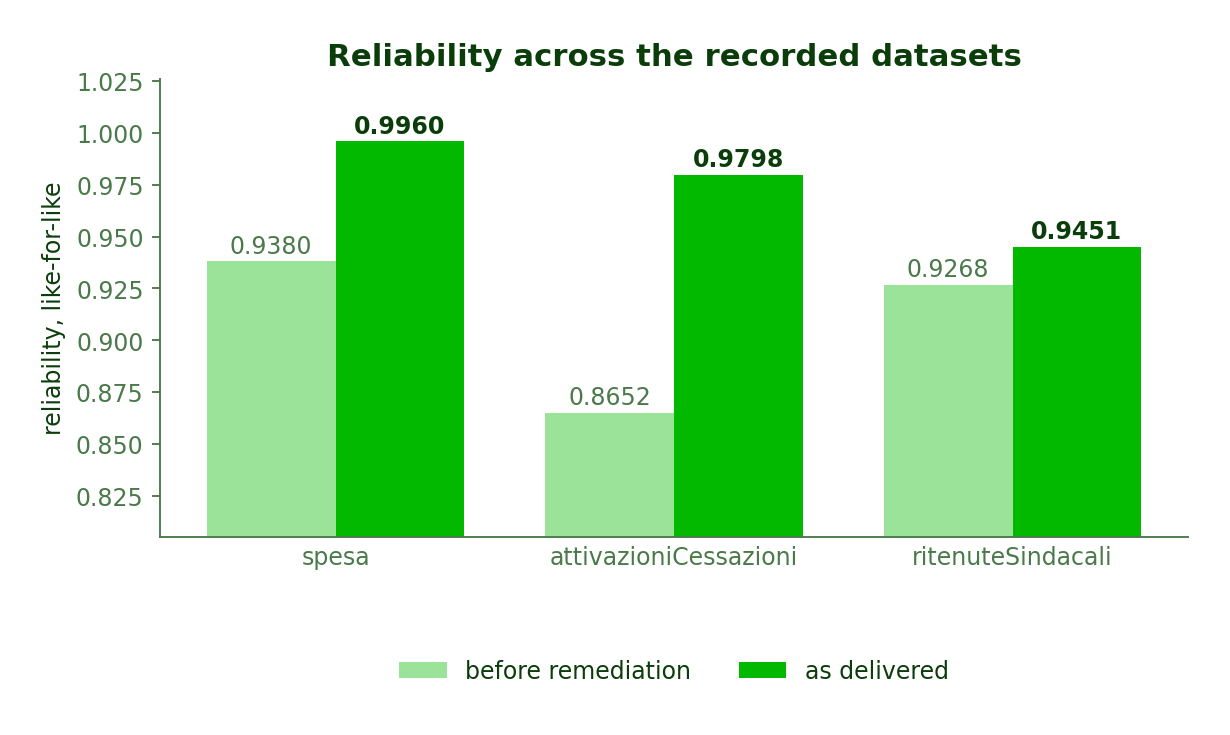

In [210]:
across = {label.split(" (")[0]: report_payload for label, report_payload in reports.items()}
display(Image(figures.to_png(figures.reliability_across_datasets(across))))

**Barely any of these files is named in the registry.** One column of eighteen for `spesa`, one of
nineteen for `attivazioniCessazioni`, two of fourteen for `ritenuteSindacali`. Whatever the canonical
matcher recovers, it recovers from *descriptions and values* through the embedding index — not from
names — and the format specs and cross-column rules are inferred and mined rather than looked up.

The two required files improved on every dimension. `ritenuteSindacali`, which the pipeline was
never developed against, improved on four of five: it mined four cross-column rules unaided,
including an arithmetic identity it was never told about, and closed **completeness to zero** — not
one null cell in the delivered file. It also shows where the limit is, which is the more useful half
of the result. Schema conformity did not move at all, 174 format violations and 1,020 consistency
violations still stand, and 82 rows remain locked in key collisions the pipeline reports rather than
resolves. Like-for-like it went 0.9268 to 0.9451, against 0.9380 to 0.9960 on the file it was built
around.

That is good evidence the system is **not fitted to the two files it was developed against**, and
equally good evidence that grounding matters: the further a file sits from the registry, the more of
its defects the pipeline can only name.

## 16. What we would tell a reviewer

**What the system does.** It measures a raw CSV against a canonical model and against itself, attaches a corrective action to every defect it finds, applies only what a human approves, and delivers the dataset with a cell-level audit trail, a report, and a reliability score computed the same way at both ends of the run.

**What the contribution actually is.** Not that an LLM can clean data. That an LLM pipeline can be made **accountable** for data repair, by dividing authority according to the kind of defect: deterministic tools measure, models reason only over bounded evidence, typed operations bound what may be executed, invariants enforce what a prompt cannot, and a human owns every decision that changes the shape of the data.

**Where it is weak, stated plainly.**

- The registry is hand-curated for NoiPA. Applying this elsewhere means writing a new registry, not retraining anything.
- Anomalies are reported, never corrected. An outlier is unusual, which is not the same as wrong.
- Generated code is a pure scalar transform, so it structurally cannot express a repair that reads another column. Those go through the typed catalogue, and where the catalogue has no matching operation the violation is carried to the report unaddressed.
- Duplicate detection is exact plus key-collision, not fuzzy record linkage.
- Run-to-run reproducibility holds for the measurements, not for everything downstream of a model. Every recording of `spesa.csv` reproduced all three quality snapshots exactly — the same 7,543 x 18 arrival, the same 16,939 nulls, the same 988 disguised ones, the same delivered 0.9801 completeness. The proposal stage did not: three recordings produced six, four and six proposals. Nor did the auto-remediated cell counts, and that is the more interesting half. A deterministic stage inherits the variance of the frame handed to it: `round_decimals` runs on `spesa` *after* `duplicate_column` has collapsed `{spesa, SPESA TOTALE}` into one column, the two sources disagree about how much rounding they need (2,830 cells against 2,817), and which name survives that collapse is a model call. `temperature=0` bounds the variance; it does not remove it.
- The gate assumes an informed reviewer. Showing the generated source verbatim is the right thing to do, but it presumes someone able to read it.

**Where we would go next.** The accept / reject / revise record is a labelled dataset of what a domain expert considers a good repair, and nothing currently consumes it. Feeding rejections back into the Unified prompt across runs would let the system converge on a particular administration's conventions — which is the natural next step for a design whose whole argument is that the human decision is the part worth keeping.